## **CompBioMed Seminars**

**Using Machine Learning for Site of Origin Prediction in Ventricular Arrhythmias from ECGs and Clinical Data**


To run the ECG Data Segmentation section:

Use Python 3.8
Install Torch
Use this command: 
pip install git+https://github.com/guillermo-jimenez/sak.git

Once you have processed the Teknon data and built your design matrix, you can create a Python environment with a more modern version.

### 1. Load Datasets

#### 1.1. .mat Datasets (DS-2496, DS-43, DS-334).

In [1]:
import numpy as np 
from scipy import signal
from sklearn.preprocessing import normalize
from scipy.io import loadmat
import pickle
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def _handle_sublocation(dSim: dict, 
                        data_key: str, 
                        path: str, 
                        X: np.ndarray, 
                        y: np.ndarray) -> (np.ndarray, np.ndarray, np.ndarray):
    """
    Handle sublocation classification and remove invalid samples.
    """

    mapping = {
        'LCC': 0, 'RCC': 1, 'COMMISSURE': 2, 'LVOT Subvalvular': 3,
        'LVOT Summit': 4, 'RVOT Septum': 5, 'RFW': 6 #RVOT Free Wall
    }

    #Dataset-specific exclusions
    if path == 'data/QRS_CARTO2.mat':
        invalid_labels = ['RV', []]
    elif path == 'data/QRS_Database2.mat':
        invalid_labels = ['-', 'RVOTOther']
    else:
        invalid_labels = []

    raw_labels = dSim[data_key]["Sublocation"]

    y_sub = []
    valid_indices = []
    unique_labels = []

    for i, label in enumerate(raw_labels[0]):

        try:   
            if label[0] in invalid_labels:
                continue
            
            else:
                if label[0] == 'LCCRCC' or label[0] == 'LCC-RCC':
                    label = 'COMMISSURE'
                
                elif label[0] == 'Posteroseptal' or label[0] == 'Anteroseptal':
                    label = 'RVOT Septum'

                elif label[0] == "AMC":
                    label = 'LVOT Subvalvular'

                elif label[0] == "Summit":
                    label = 'LVOT Summit'
                
                else:
                    label = label[0]

                if label in mapping:
                    y_sub.append(mapping[label])
                    valid_indices.append(i)
                    if label not in unique_labels:
                        unique_labels.append(label)
                else:
                    print(f"Warning: unknown sublocation '{label}' at index {i}")

        except:
            print(f"Warning: invalid label format at index {i}: {label}")
            continue


    print(f"Unique sublocation labels found: {unique_labels}")
    #Filter dataset
    X = X[valid_indices]
    y = y[valid_indices]
    y_sub = np.array(y_sub)

    return X, y, y_sub

In [3]:
def _build_binary_target(dSim: dict, 
                         data_key: str) -> np.ndarray:
    """
    Build LV (0) vs RV (1) classification target.
    """

    mapping = {"LV": 0, "RV": 1}
    #Handle typo inconsistency in datasets
    key_name = "LeftRight" if "LeftRight" in dSim[data_key].dtype.names else "LeftRigth"
    
    raw_labels = dSim[data_key][key_name]
    y = np.zeros(len(raw_labels[0]))

    for i, label in enumerate(raw_labels[0]):
        y[i] = mapping[label[0]]

    return y

In [4]:
def _load_mat_dataset(path, sample_size, data_key,
                      lead_names, sublocation):
    """
    Internal function to load .mat ECG datasets.
    """
    #dSim has the data at data_key (e.g., QRS_CARTO), and then for each lead, we have a (1, n_patients) list, where each entry is a (n_samples,) array with the ECG signal for that patient and lead.
    dSim = loadmat(path)

    #Number of patients
    n_patients = dSim[data_key][lead_names[0]].shape[1]
    print(f"Number of patients: {n_patients}")

    #Allocate matrix: (patients × (leads * samples))
    X = np.zeros((n_patients, len(lead_names) * sample_size))

    #Build feature matrix
    for iLead, lead in enumerate(lead_names):
        lead_data = dSim[data_key][lead]

        for i in range(n_patients):
            patient_signal = lead_data[0, i]
            signal_1d = np.asarray(patient_signal).squeeze() #Convert to 1D array

            #Safety check
            if signal_1d.ndim != 1:
                raise ValueError(
                    f"Invalid ECG shape at patient {i}, lead {lead}: {signal_1d.shape}"
                )
            #Resample signal to fixed length
            resampled = signal.resample(signal_1d, sample_size).flatten()

            # Place in correct position
            start = iLead * sample_size
            end = (iLead + 1) * sample_size
            X[i, start:end] = resampled

    #Normalize (important for ML stability)
    X = normalize(X, norm="l1")

    #Build targets
    y = _build_binary_target(dSim, data_key)

    if sublocation:
        X, y, y_sub = _handle_sublocation(dSim, data_key, path, X, y)

    return {
        "data": X,
        "target": y
    }
  

In [5]:
def load_dataset(path: str, 
                 sample_size: int, 
                 data_key: str,
                 lead_names: list = None,
                 sublocation: bool = False,
                 shuffle: bool = True,
                 random_state: int = None):
    """
    Load ECG dataset and return (X, y).

    This function:
    1. Loads raw ECG data
    2. Resamples each lead
    3. Flattens all 12 leads into a single vector per patient
    4. Normalizes the data
    5. Builds target labels

    Parameters
    ----------
    path : str
        Path to .mat file
    sample_size : int
        Number of samples per lead after resampling
    data_key : str
        Key inside .mat file (e.g. 'QRS')
    lead_names : list
        ECG leads to use (default: standard 12-lead)
    sublocation : bool
        If True, also compute sublocation labels
    shuffle : bool
        Whether to shuffle dataset
    random_state : int or None
        Seed for reproducibility

    Returns
    -------
    X : np.ndarray
        Shape (n_samples, n_leads * sample_size)
    y : np.ndarray
        Binary labels (LV=0, RV=1)
    """

    if lead_names is None:
        lead_names = ["I","II","III","aVR","aVL","aVF",
                      "V1","V2","V3","V4","V5","V6"]

    print(f"Loading dataset from: {path}")

    # Load and process raw data
    DB_dict = _load_mat_dataset(path, sample_size, data_key,
                                lead_names, sublocation)

    X = DB_dict["data"]
    y = DB_dict["target"]

    # Shuffle if needed
    if shuffle:
        rng = np.random.default_rng(random_state)
        indices = rng.permutation(len(X))
        X = X[indices]
        y = y[indices]

    return X, y

In [6]:
"""#1. Load QRS_Carto2.mat
X_Clinic, y_Clinic = load_dataset('data/QRS_CARTO2.mat', sample_size=10, data_key='QRS_CARTO', lead_names=["I","II","III","aVR","aVL","aVF",
                      "V1","V2","V3","V4","V5","V6"], sublocation=True, shuffle=False, random_state=42)

 """

'#1. Load QRS_Carto2.mat\nX_Clinic, y_Clinic = load_dataset(\'data/QRS_CARTO2.mat\', sample_size=10, data_key=\'QRS_CARTO\', lead_names=["I","II","III","aVR","aVL","aVF",\n                      "V1","V2","V3","V4","V5","V6"], sublocation=True, shuffle=False, random_state=42)\n\n '

In [7]:
#2. Load QRS_Database2.mat
#X_China, y_China = load_dataset('data/QRS_Database2.mat', sample_size=10, data_key='QRS', lead_names=["I","II","III","aVR","aVL","aVF",
                     # "V1","V2","V3","V4","V5","V6"], sublocation=True, shuffle=False, random_state=42)

In [8]:
#3. Load QRS_Sims2.mat
#X_Sims, y_Sims = load_dataset('data/QRS_Sims2.mat', sample_size=10, data_key='QRS_Sims', lead_names=["I","II","III","aVR","aVL","aVF",
                    #  "V1","V2","V3","V4","V5","V6"], sublocation=True, shuffle=False, random_state=42)

### 1.2. Load Teknon Dataset

In [9]:
teknon = pickle.load(open('data/full_data_corrected_2024.pkl', 'rb'))

#A. CLINICAL DATA
#Using all the patients in data (first keys), create a .csv with these subkeys:
subkeys = ['Sex', 'HTA', 'Age', 'PVC_transition', 'SOO_chamber', 'Height', 'Weight', 'BMI', 'DM', 'DLP', 'Smoker', 'COPD', 'Sleep_apnea', 'CLINICAL_SCORE', 'SOO', 'OTorigin']

#OTorigin is 1 if "OT" is in the SOO_chamber, otherwise 0. This is not the final RVOT/LVOT origin label, which you will have to build! :)
print(teknon.keys())
clinical_df = pd.DataFrame(columns=subkeys)

#Each clinical subkey is a key of the teknon dictionary
for subkey in subkeys:
    clinical_data = teknon[subkey]
    #This is now a column of the dataframe
    clinical_df[subkey] = clinical_data

display(clinical_df)
print(clinical_df.shape)

dict_keys(['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'Sex', 'HTA', 'Age', 'PVC_transition', 'SOO_chamber', 'Height', 'Weight', 'BMI', 'DM', 'DLP', 'Smoker', 'COPD', 'Sleep_apnea', 'CLINICAL_SCORE', 'SOO', 'OTorigin'])


,Sex,HTA,Age,PVC_transition,SOO_chamber,Height,Weight,BMI,DM,DLP,Smoker,COPD,Sleep_apnea,CLINICAL_SCORE,SOO,OTorigin
0,Female,NaN,61.0,V1,Right ventricle,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unión mitroaórtica,0.0
1,Female,No,52.0,V3,RVOT,169.0,68.0,NaN,No,No,No,No,No,1.0,Pared libre anterior,1.0
2,Female,No,69.0,V3,LVOT,156.0,70.0,NaN,No,Yes,No,No,No,1.0,RCC,1.0
3,Female,No,66.0,V4,Right ventricle,176.0,63.0,20.338326,No,No,No,No,No,1.0,M. papilar posteromedial,0.0
4,Female,Yes,46.0,V3,RVOT,160.0,79.0,30.859375,No,No,No,No,No,1.0,RVOT septal,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,Male,Yes,61.0,V1,Right ventricle,188.0,90.0,25.464011,No,No,No,No,No,3.0,LV summit,0.0
177,Male,Yes,52.0,V3,LVOT,182.0,83.0,25.057360,No,No,No,No,No,3.0,Seno de Valsalva dcho.,1.0
178,Male,No,77.0,V6,Right ventricle,NaN,NaN,NaN,No,No,No,No,No,2.0,LV inferobasal,0.0
179,Male,Yes,88.0,V1,Mitral annulus,166.0,90.0,NaN,Yes,Yes,No,No,No,3.0,Anillo mitral anterolateral,0.0


(181, 16)


In [10]:
#### VERY IMPORTANT #####
#### FINAL TEST SET DEFINITION ####

#We define the final test set where the final model configuration will be evaluated. This will be the last 20% of the Teknon data.
test_set = clinical_df.iloc[int(0.8*len(clinical_df)):]
train_set=clinical_df.iloc[:int(0.8*len(clinical_df))]

In [11]:
def standardize_soo(text):
    if pd.isna(text):
        return None
    
    # Normalitzem el text: minúscules i treure accents per seguretat
    text = text.lower().strip()
    text = text.replace('í', 'i').replace('á', 'a').replace('ó', 'o')
    
    # 1. EXCEPCIONS I NO MAPPEJATS (Fascicles i Anells Laterals genèrics)
    if any(word in text for word in ['fasciculo', 'anillo lat']):
        return None
    
    # 2. RVOT SEPTUM (Prioritat alta)
    # Incloem: septo, septal, SC, tricuspídeo, infundíbulo
    if any(word in text for word in ['septo', 'septal', 'sc', 'tricuspideo', 'infu']):
        # Excepció: si és LV + Septum, va a Free Wall
        if 'lv' in text:
            return 'RFW'
        return 'RVOT Septum'
    
    # 3. RFW (RVOT Free Wall)
    # Incloem: papilar, pared libre, banda moderadora, rvot
    if any(word in text for word in ['papilar', 'pared libre', 'banda moderadora', 'rvot']):
        return 'RFW'
    
    # 4. LVOT SUMMIT
    if 'summit' in text:
        return 'LVOT Summit'
    
    # 5. LVOT SUBVALVULAR
    # Incloem: mitral, lv, infero, mitroaórtica
    if any(word in text for word in ['mitral', 'lv', 'infero', 'mitroaortica']):
        return 'LVOT Subvalvular'
    
    # 6. RCC
    if any(word in text for word in ['rcc', 'iv anterior', 'valsalva derecho', 'dcho']):
        return 'RCC'
    
    # 7. LCC
    if any(word in text for word in ['lcc', 'izquierd', 'izdo', 'valsalva izq']):
        return 'LCC'
    
    # 8. COMMISURE
    if any(word in text for word in ['intersenos', 'intersinus']):
        return 'COMMISURE'
    
    return None

# Apliquem el canvi
train_set['SOO_std'] = train_set['SOO'].apply(standardize_soo)

# Comprovem els nous recomptes
print(train_set['SOO_std'].value_counts())

SOO_std
RVOT Septum         50
RFW                 42
LVOT Subvalvular    24
LVOT Summit         11
RCC                  9
LCC                  3
COMMISURE            1
Name: count, dtype: int64


C:\Users\senyo\AppData\Local\Temp\ipykernel_23940\4240816578.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_set['SOO_std'] = train_set['SOO'].apply(standardize_soo)


In [12]:
# Valors no mapejats -- els eliminem
print("\nValors NO mapejats:")
print(train_set[train_set['SOO_std'].isna()]['SOO'].value_counts())

# Elimina qualsevol fila on 'SOO_std' sigui None o NaN
train_set_ot = train_set.dropna(subset=['SOO_std']).copy()

display(train_set_ot)
print(train_set_ot.shape)


Valors NO mapejats:
SOO
fasciculo anterior LV    1
anillo lat               1
Fascículo anterior       1
Name: count, dtype: int64


,Sex,HTA,Age,PVC_transition,SOO_chamber,Height,Weight,BMI,DM,DLP,Smoker,COPD,Sleep_apnea,CLINICAL_SCORE,SOO,OTorigin,SOO_std
0,Female,NaN,61.0,V1,Right ventricle,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unión mitroaórtica,0.0,LVOT Subvalvular
1,Female,No,52.0,V3,RVOT,169.0,68.0,NaN,No,No,No,No,No,1.0,Pared libre anterior,1.0,RFW
2,Female,No,69.0,V3,LVOT,156.0,70.0,NaN,No,Yes,No,No,No,1.0,RCC,1.0,RCC
3,Female,No,66.0,V4,Right ventricle,176.0,63.0,20.338326,No,No,No,No,No,1.0,M. papilar posteromedial,0.0,RFW
4,Female,Yes,46.0,V3,RVOT,160.0,79.0,30.859375,No,No,No,No,No,1.0,RVOT septal,1.0,RVOT Septum
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,Female,No,57.0,V3,RVOT,155.0,74.0,30.801249,No,Yes,No,No,No,1.0,RVOT medioseptal,1.0,RVOT Septum
140,Female,No,30.0,V4,RVOT,160.0,53.0,20.703125,No,No,No,No,No,0.0,RVOT posteroseptal,1.0,RVOT Septum
141,Male,No,43.0,V1,Right ventricle,173.0,77.0,NaN,No,No,No,No,No,1.0,Papilar anterolateral,0.0,RFW
142,Male,No,39.0,V3,RVOT,150.0,43.0,NaN,No,No,No,No,No,0.0,rvot septal anterior,1.0,RVOT Septum


(140, 17)


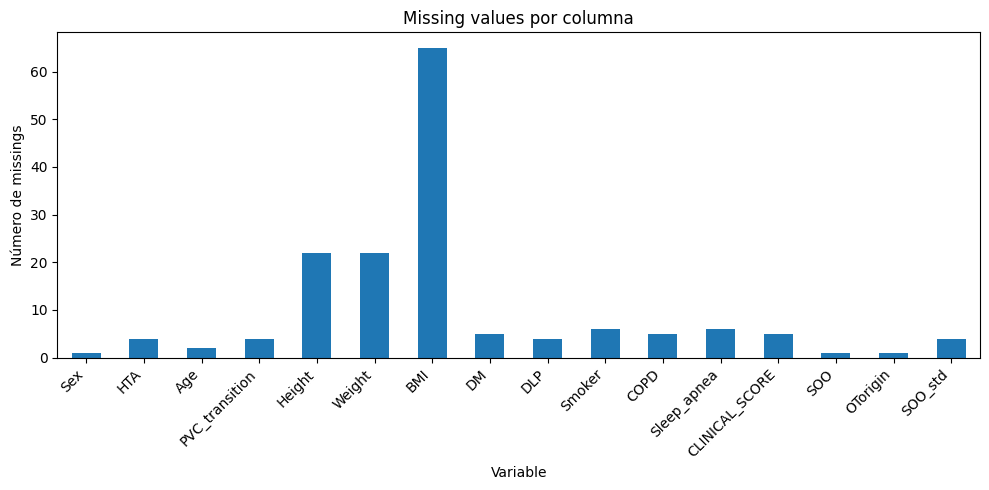


Pacientes después de filtrar: 140
['Sex', 'HTA', 'Age', 'PVC_transition', 'SOO_chamber', 'Height', 'Weight', 'BMI', 'DM', 'DLP', 'Smoker', 'COPD', 'Sleep_apnea', 'CLINICAL_SCORE', 'SOO', 'OTorigin', 'SOO_std']
Sex                1
HTA                4
Age                2
PVC_transition     4
Height            22
Weight            22
BMI               65
DM                 5
DLP                4
Smoker             6
COPD               5
Sleep_apnea        6
CLINICAL_SCORE     5
SOO                1
OTorigin           1
SOO_std            4
dtype: int64


In [13]:
missing = train_set.isnull().sum()
missing = missing[missing > 0]  # solo columnas con missings

# BMI, height and weight can be taken out of the data as it does not really yield important information for the algorithm as most of the values are missing

plt.figure(figsize=(10, 5))
missing.plot(kind='bar')
plt.title('Missing values por columna')
plt.ylabel('Número de missings')
plt.xlabel('Variable')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nPacientes después de filtrar:", len(train_set_ot))
print(train_set_ot.columns.tolist())
print(missing)

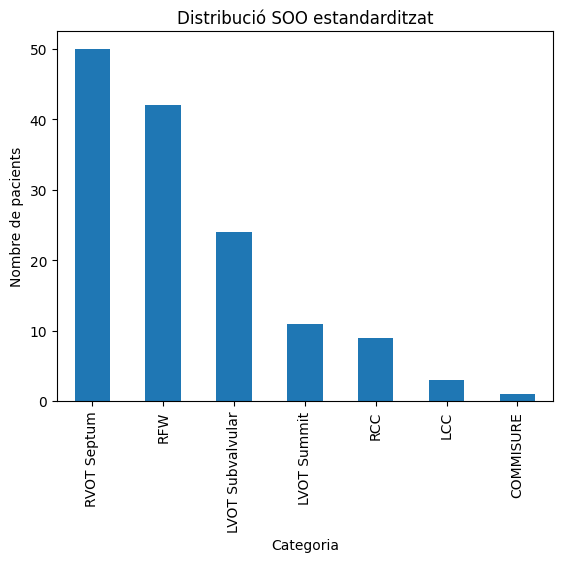

In [14]:
# Gràfic de distribució final
train_set['SOO_std'].value_counts().plot(kind='bar')
plt.title("Distribució SOO estandarditzat")
plt.xlabel("Categoria")
plt.ylabel("Nombre de pacients")
plt.show()

In [15]:
import pandas as pd
import scipy.stats as stats

# 1. Configuració de la divisió de dades
# Suposem que 'SOO' és el teu target. Canvia-ho si té un altre nom.
target_col = 'SOO' 

split_idx = int(0.8 * len(train_set))
train_df = train_set.iloc[:split_idx].copy()
test_df  = train_set.iloc[split_idx:].copy()

# Definir y_train com a Series (important per al .unique())
y_train = train_df[target_col]

# 2. Definició de les variables per tipus
# Hem afegit Weight, Height i BMI aquí
numerical_features = ['Age', 'Weight', 'Height', 'BMI']
ordinal_features   = ['PVC_transition']
binary_features    = ['Sex', 'HTA']

# Mapatge per a variables ordinals (Kruskal-Wallis necessita números, no text)
pvc_map = {val: i for i, val in enumerate(['V1', 'V2', 'V3', 'V4', 'V5', 'V6'])}
train_df['PVC_numeric'] = train_df['PVC_transition'].map(pvc_map)

associations = []

# Afegeix això abans de començar els bucles per assegurar format numèric
for col in numerical_features:
    train_df[col] = pd.to_numeric(train_df[col], errors='coerce')

# Re-inicialitzem la llista de resultats
associations = []

# ── ANOVA robust ──────────────────────────────────────────────────────────
for feature in numerical_features:
    # Filtrem grups: han de tenir dades i més d'un element per ser estadísticament vàlids
    groups = [train_df.loc[y_train == soo, feature].dropna() 
              for soo in y_train.unique()]
    
    # Només fem el test si hi ha almenys 2 grups i cada grup té dades
    groups = [g for g in groups if len(g) > 1]
    
    if len(groups) > 1:
        f_stat, p_value = stats.f_oneway(*groups)
    else:
        f_stat, p_value = (None, None) # No hi ha prou dades per al test
        
    associations.append({'Feature': feature, 'Test': 'ANOVA', 'Statistic': f_stat, 'p-value': p_value})

# ── Kruskal-Wallis robust ────────────────────────────────────────────────
for feature in ordinal_features:
    groups = [train_df.loc[y_train == soo, 'PVC_numeric'].dropna() 
              for soo in y_train.unique()]
    
    groups = [g for g in groups if len(g) > 0]
    
    if len(groups) > 1:
        h_stat, p_value = stats.kruskal(*groups)
    else:
        h_stat, p_value = (None, None)
        
    associations.append({'Feature': feature, 'Test': 'Kruskal-Wallis', 'Statistic': h_stat, 'p-value': p_value})


# ── Chi-cuadrat per a variables binàries (Sex, HTA) ──────────────────────
for feature in binary_features:
    contingency_table = pd.crosstab(train_df[feature], y_train)
    
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
    associations.append({
        'Feature': feature,
        'Test': 'Chi-cuadrado',
        'Statistic': chi2,
        'p-value': p_value
    })

# ── Resultats ─────────────────────────────────────────────────────────────
df_associations = pd.DataFrame(associations)
df_associations['Significant (p<0.05)'] = df_associations['p-value'] < 0.05

# Ordenem per rellevància (p-value més baix primer)
display(df_associations.sort_values(by='p-value'))

,Feature,Test,Statistic,p-value,Significant (p<0.05)
4,PVC_transition,Kruskal-Wallis,91.809848,0.005143,True
0,Age,ANOVA,2.075749,0.025399,True
6,HTA,Chi-cuadrado,65.736232,0.316253,False
1,Weight,ANOVA,0.871692,0.598270,False
3,BMI,ANOVA,0.758040,0.686520,False
2,Height,ANOVA,0.771038,0.699763,False
5,Sex,Chi-cuadrado,55.111190,0.719942,False


In [16]:
# Eliminem BMI, weight, height -- no tenen relacio i tenen molts de NaNs

train_set = train_set.drop(columns=['BMI', 'Weight', 'Height']) 
# Visualitzar el resultat
display(train_set.head())
print(train_set.shape)

,Sex,HTA,Age,PVC_transition,SOO_chamber,DM,DLP,Smoker,COPD,Sleep_apnea,CLINICAL_SCORE,SOO,OTorigin,SOO_std
0,Female,NaN,61.0,V1,Right ventricle,NaN,NaN,NaN,NaN,NaN,NaN,Unión mitroaórtica,0.0,LVOT Subvalvular
1,Female,No,52.0,V3,RVOT,No,No,No,No,No,1.0,Pared libre anterior,1.0,RFW
2,Female,No,69.0,V3,LVOT,No,Yes,No,No,No,1.0,RCC,1.0,RCC
3,Female,No,66.0,V4,Right ventricle,No,No,No,No,No,1.0,M. papilar posteromedial,0.0,RFW
4,Female,Yes,46.0,V3,RVOT,No,No,No,No,No,1.0,RVOT septal,1.0,RVOT Septum


(144, 14)


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
#StandardScaler: media 0, desviacion estandar 1

# DEFINIR FEATURES
numerical_features = ['Age']
ordinal_features   = ['PVC_transition']
binary_features    = ['Sex', 'HTA']
pvc_order = [['V1', 'V2', 'V3', 'V4', 'V5', 'V6']]

# PREPROCESSING PIPELINE
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

ordinal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=pvc_order)),
    #('scaler', StandardScaler())
])

binary_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('ord', ordinal_pipeline,   ordinal_features),
        ('bin', binary_pipeline,    binary_features),
    ],
    remainder='drop'
)


# FIT I TRANSFORM SOLO SOBRE TRAIN
X_train = train_df[numerical_features + ordinal_features + binary_features]
X_train_array = preprocessor.fit_transform(X_train)

feature_names = preprocessor.get_feature_names_out()
X_train_preprocessed = pd.DataFrame(
    X_train_array,
    columns=feature_names,
    index=X_train.index
)

print("\nOriginal X_train shape:", X_train.shape)
print("Preprocessed X_train shape:", X_train_preprocessed.shape)
print("\nX_train preprocessed:")
display(X_train_preprocessed.head())


Original X_train shape: (115, 4)
Preprocessed X_train shape: (115, 4)

X_train preprocessed:


,num__Age,ord__PVC_transition,bin__Sex_Male,bin__HTA_Yes
0,0.269483,0.0,0.0,0.0
1,-0.303237,2.0,0.0,0.0
2,0.778567,2.0,0.0,0.0
3,0.587661,3.0,0.0,0.0
4,-0.685051,2.0,0.0,1.0


##### ECG Data Segmentation

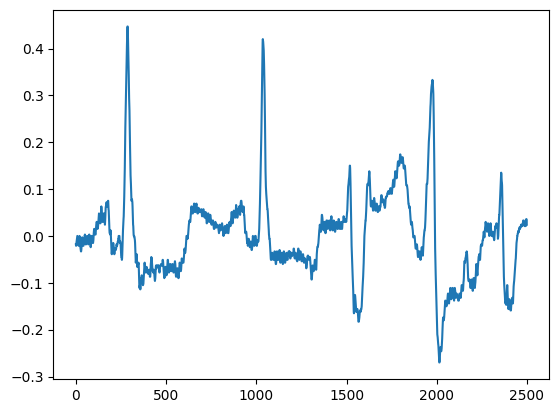

In [18]:
#B. ECG DATA
#The Teknon dataset has ECG signals with 4 beats, the last of which corresponds to the PVC. 
#Using the given segmentation models at models/, you will be able to retrieve all the P, QRS and T waves.

#Of course, you can also use the entire signal as input for your models. In that case, take into account that each lead has different value ranges.
#Moreover, you won't be able to combine your data with the other datasets, since they are segmented in QRS complexes.

#Plot one sample
plt.plot(teknon['I'][0])

In [19]:
#Example with ECG segmentation
import torch
import sak
from functools import partial
import math
import scipy as sp
import skimage
import skimage.util
from typing import List,Tuple
import numpy as np

models_ECG = [
    torch.load(f"models/model.{i+1}", weights_only=False) for i in range(5)
]

c:\Users\senyo\Documentos\GitHub\Ciencia-de-dades-i-models-computacionals-en-biomedicina-\venv38\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\senyo\Documentos\GitHub\Ciencia-de-dades-i-models-computacionals-en-biomedicina-\venv38\lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [20]:
from typing import List
def predict_ecg(ecg: np.ndarray, fs: float, model: List[torch.nn.Module],
                window_size: int = 2048, stride: int = 256, threshold_ensemble: float = 0.5,
                thr_dice=0.9, percentile=95, ptg_voting = 0.5, batch_size = 16,
                normalize=True, norm_threshold: float = 1e-6, filter = True) -> np.ndarray:
    """This function is used to delineate an ECG recording of arbitrary size ('ecg' variable, SAMPLES x LEADS)
    and to obtain the fiducials for the P, QRS and T segments as a binary mask of shape 3 x SAMPLES.

    Inputs:
    ecg                <- some array, e.g. shape 198484 x 12
    fs                 <- sampling frequency, e.g. 1000Hz. Will downsample to 250Hz for the AI model to work
    model              <- list of segmentation models for the ensemble
    window_size        <- the "chunk" size that will be processed at a time of the input ecg (e.g., in the example,
                          2048 samples out of the 198484 samples of the ECG)
    stride             <- the "stride" parameter allows for some overlap between the windows of the window_size
    threshold_ensemble <- Percentage of voting for the AI ensemble [0-1]
    thr_dice           <- Threshold for considering each sample as positive according to the Dice score
    percentile         <- Percentile for the amplitude normalization
    ptg_voting         <- Threshold for considering each sample as positive according to the Dice score
    batch_size         <- Number of windows that fit in the batch
    normalize          <- Boolean to indicate whether the ECG has to be normalized. In general, set this to True
                          always, as the ECGs must have the amplitude of a normal sinus rhythm around amplitude of
                          "1" to work, as that was the preprocessing for model training. Only change if a
                          comparable pre-processing is performed
    norm_threshold     <- Threshold for the normalization, to avoid passing baseline wander or noise as signal
    filter             <- Filter the signal with a band-pass filter in [0.5-125] Hz
    """
    # Preprocess signal
    ecg = np.copy(ecg).squeeze()
    if ecg.ndim == 0:
        return np.array([])
    elif ecg.ndim == 1:
        ecg = ecg[:,None]
    elif ecg.ndim == 2:
        if ecg.shape[0] < ecg.shape[1]:
            ecg = ecg.T
    else:
        raise ValueError("2 dims max allowed")
    
    #Resample to 250Hz if necessary
    if fs != 250:
        ecg_250 = sp.signal.resample(ecg, int(ecg.shape[0]*250/fs), axis=0)
    else:
        ecg_250 = ecg

    # Pad if necessary
    if ecg_250.shape[0] < window_size:
        padding = math.ceil(ecg_250.shape[0]/window_size)*window_size-ecg_250.shape[0]
        ecg_250 = np.pad(ecg_250,((0,padding),(0,0)),mode='edge')
    if (ecg_250.shape[0]-window_size)%stride != 0:
        padding = math.ceil((ecg_250.shape[0]-window_size)/stride)*stride-(ecg_250.shape[0]%window_size)
        ecg_250 = np.pad(ecg_250,((0,padding),(0,0)),mode='edge')

    # Get dimensions
    N,L = ecg_250.shape

    # (Optional) Normalize amplitudes
    if normalize:
        # Get ecg_250 when it's not flat zero
        norm_signal = ecg_250[np.all(np.abs(np.diff(ecg_250,axis=0,append=0)) >= norm_threshold,axis=1),:]

        # High pass filter normalized ecg_250 to avoid issues with baseline wander
        norm_signal = sp.signal.filtfilt(*sp.signal.butter(2, 0.5/250., 'high'),norm_signal, axis=0)

        # Compute amplitude for those segments
        amplitude = np.array(sak.signal.moving_lambda(
            norm_signal,
            256,
            partial(sak.signal.amplitude,axis=0),
            axis=0
        ))
        amplitude = amplitude[np.all(amplitude > norm_threshold,axis=1),]
        amplitude = np.percentile(amplitude, percentile, axis=0)

        # Apply normalization
        ecg_250 = ecg_250/amplitude[None,:]

    # (Optional) Filter ecg_250
    if filter:
        ecg_250 = sp.signal.filtfilt(*sp.signal.butter(2,   0.5/250., 'high'),ecg_250,axis=0)
        ecg_250 = sp.signal.filtfilt(*sp.signal.butter(2, 125.0/250.,  'low'),ecg_250,axis=0)
        ecg_250 = sp.signal.lfilter(*sp.signal.iirnotch(50,20.0,250.),ecg_250,axis=0)
        ecg_250 = sp.signal.lfilter(*sp.signal.iirnotch(60,20.0,250.),ecg_250,axis=0)

    # Avoid issues with negative strides due to filtering:
    if np.any(np.array(ecg_250.strides) < 0):
        ecg_250 = ecg_250.copy()

    # Data structure for computing the segmentation
    windowed_signal = skimage.util.view_as_windows(ecg_250,(window_size,1),(stride,1))

    # Flat batch shape
    new_shape = (windowed_signal.shape[0]*windowed_signal.shape[1],*windowed_signal.shape[2:])
    windowed_signal = np.reshape(windowed_signal,new_shape)

    # Exchange channel position
    windowed_signal = np.swapaxes(windowed_signal,1,2)

    # Output structures
    windowed_mask = np.zeros((windowed_signal.shape[0],3,windowed_signal.shape[-1]),dtype=int)

    # Check device for segmentation
    device = "mps" if torch.backends.mps.is_available() else "cpu"

    # Compute segmentation for all leads independently
    with torch.no_grad():
        if isinstance(model,list):
            for m in model:
                m = m.to(device)
                for i in range(0,windowed_signal.shape[0],batch_size):
                    inputs = {"x": torch.tensor(windowed_signal[i:i+batch_size]).float().to(device)}
                    outputs = m(inputs)["sigmoid"].cpu().detach().numpy()
                    windowed_mask[i:i+batch_size] += outputs > thr_dice
            windowed_mask = windowed_mask >= len(model)*threshold_ensemble
        else:
            model = model.to(device)
            for i in range(0,windowed_signal.shape[0],batch_size):
                inputs = {"x": torch.tensor(windowed_signal[i:i+batch_size]).to(device).float()}
                outputs = model(inputs)["sigmoid"].cpu().detach().numpy()
                windowed_mask[i:i+batch_size] = outputs > thr_dice

    # Retrieve mask as 1D
    counter = np.zeros((N), dtype=int)
    segmentation_250 = np.zeros((3,N))

    # Iterate over windows
    for i in range(0,windowed_mask.shape[0],L):
        counter[(i//L)*stride:(i//L)*stride+window_size] += 1
        segmentation_250[:,(i//L)*stride:(i//L)*stride+window_size] += windowed_mask[i:i+L].sum(0)
    segmentation_250 = ((segmentation_250/counter) >= (ecg_250.shape[-1]*ptg_voting))

    # Correct padding
    segmentation_250 = segmentation_250[:,:-padding]

    # Interpolate back to original sampling frequency
    segmentation = sak.signal.interpolate.interp1d(segmentation_250,ecg.shape[0],axis=-1,kind="nearest")

    return segmentation

In [21]:
#Transform the signal from dictionary to numpy array
from sak.signal import StandardHeader
ecg_signals = []
for lead in StandardHeader:
    ecg_signals.append(teknon[lead][0])
ecg_signals = np.asarray(ecg_signals).T

In [22]:
#Apply the segmentation for a single record (make function to apply to multiple signals)
fs = 1000
fs_high,fs_low = 0.5,100.0

#Resample to 250 Hz
ecg_250 = sak.signal.interpolate.interp1d(ecg_signals, round(ecg_signals.shape[0]*250/fs), axis=0).T
#Bandpass filter
ecg_250 = sp.signal.filtfilt(*sp.signal.butter(2, fs_high/250., 'high'), ecg_250, axis=-1)
ecg_250 = sp.signal.filtfilt(*sp.signal.butter(2, fs_low/250., 'low'), ecg_250, axis=-1)

#Predict segmentation
segmentation_250 = predict_ecg(ecg_250, 250., models_ECG, normalize=True, filter=False)

#Check for empty segmentation
if segmentation_250.size == 0:
    print(f"[WARN] Empty segmentation")

segmentation = sak.signal.interpolate.interp1d(segmentation_250, ecg_signals.shape[0],axis=-1,kind="nearest")

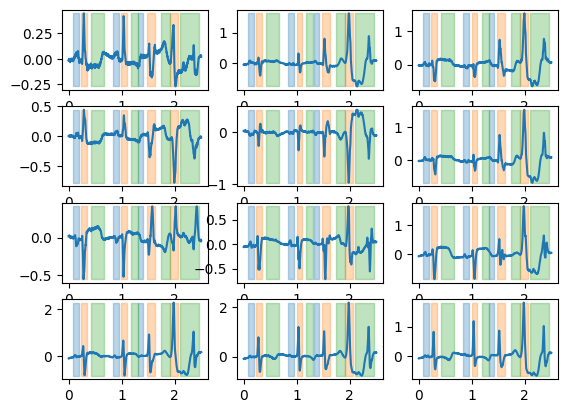

In [23]:
#Plot all the signals
fig, ax = plt.subplots(4,3)
row = 0
col = 0
x = np.linspace(0,2.5,int(fs*2.5))
for i,sig in enumerate(ecg_signals.T):
    ax[row,col].plot(x, sig)
    ax[row,col].fill_between(x, np.min(sig), np.max(sig), where=(segmentation[0,:] == 1), color='C0', alpha = 0.3 )
    ax[row,col].fill_between(x, np.min(sig), np.max(sig), where=(segmentation[1,:] == 1), color='C1', alpha = 0.3 )
    ax[row,col].fill_between(x, np.min(sig), np.max(sig), where=(segmentation[2,:] == 1), color='C2', alpha = 0.3 )
    col += 1
    if col >= 3:
        row += 1
        col = 0

In [24]:
def extract_qrs(ecg_signals, segmentation, fs=1000, beat_index=-1):
    """
    Extract QRS segment from ECG signals using segmentation mask.
    
    Parameters:
    -----------
    ecg_signals : Shape (samples, leads) - ECG signal
    segmentation : Shape (3, samples)
    fs : Sampling frequency
    beat_index : Which QRS complex to extract (-1 for last, 0 for first, etc.)
        
    Returns:
    --------
    qrs_signal : Shape (qrs_samples, leads) - ECG signal containing only QRS complex
    """
    # Get QRS mask from segmentation[1,:]
    qrs_mask = segmentation[1, :] == 1
    
    # Find transitions to identify separate QRS complexes
    qrs_diff = np.diff(qrs_mask.astype(int))
    qrs_starts = np.where(qrs_diff == 1)[0] + 1  # Where QRS starts
    qrs_ends = np.where(qrs_diff == -1)[0] + 1   # Where QRS ends
    
    print(f"Found {len(qrs_starts)} QRS complexes")
    
    if len(qrs_starts) == 0:
        print("[WARN] No QRS complexes found")
        return np.array([])
    
    # Select which QRS to extract
    if beat_index >= len(qrs_starts):
        print(f"[WARN] Beat index {beat_index} out of range, extracting last beat")
        beat_index = -1
    
    start_idx = qrs_starts[beat_index]
    end_idx = qrs_ends[beat_index]
    
    print(f"Extracting QRS complex {beat_index}: samples {start_idx} to {end_idx} (duration: {(end_idx-start_idx)/fs*1000:.1f}ms)")
    
    # Extract QRS for this specific beat
    qrs_signal = ecg_signals[start_idx:end_idx, :]
    
    return qrs_signal


In [25]:
qrs = extract_qrs(ecg_signals, segmentation, beat_index=-1)
print(f"QRS shape: {qrs.shape}")
print(f"QRS contains {qrs.shape[0]} samples from {qrs.shape[1]} leads")


Found 4 QRS complexes
Extracting QRS complex -1: samples 1913 to 2053 (duration: 140.0ms)
QRS shape: (140, 12)
QRS contains 140 samples from 12 leads


In [26]:

# DEBUG: Check segmentation
print(f"Segmentation shape: {segmentation.shape}")
print(f"Segmentation dtype: {segmentation.dtype}")
print(f"Segmentation unique values: {np.unique(segmentation)}")
print(f"QRS mask (segmentation[1,:]==1) sum: {np.sum(segmentation[1,:] == 1)}")
print(f"P mask (segmentation[0,:]==1) sum: {np.sum(segmentation[0,:] == 1)}")
print(f"T mask (segmentation[2,:]==1) sum: {np.sum(segmentation[2,:] == 1)}")
print(f"ECG signals shape: {ecg_signals.shape}")


Segmentation shape: (3, 2500)
Segmentation dtype: float64
Segmentation unique values: [0. 1.]
QRS mask (segmentation[1,:]==1) sum: 516
P mask (segmentation[0,:]==1) sum: 337
T mask (segmentation[2,:]==1) sum: 928
ECG signals shape: (2500, 12)


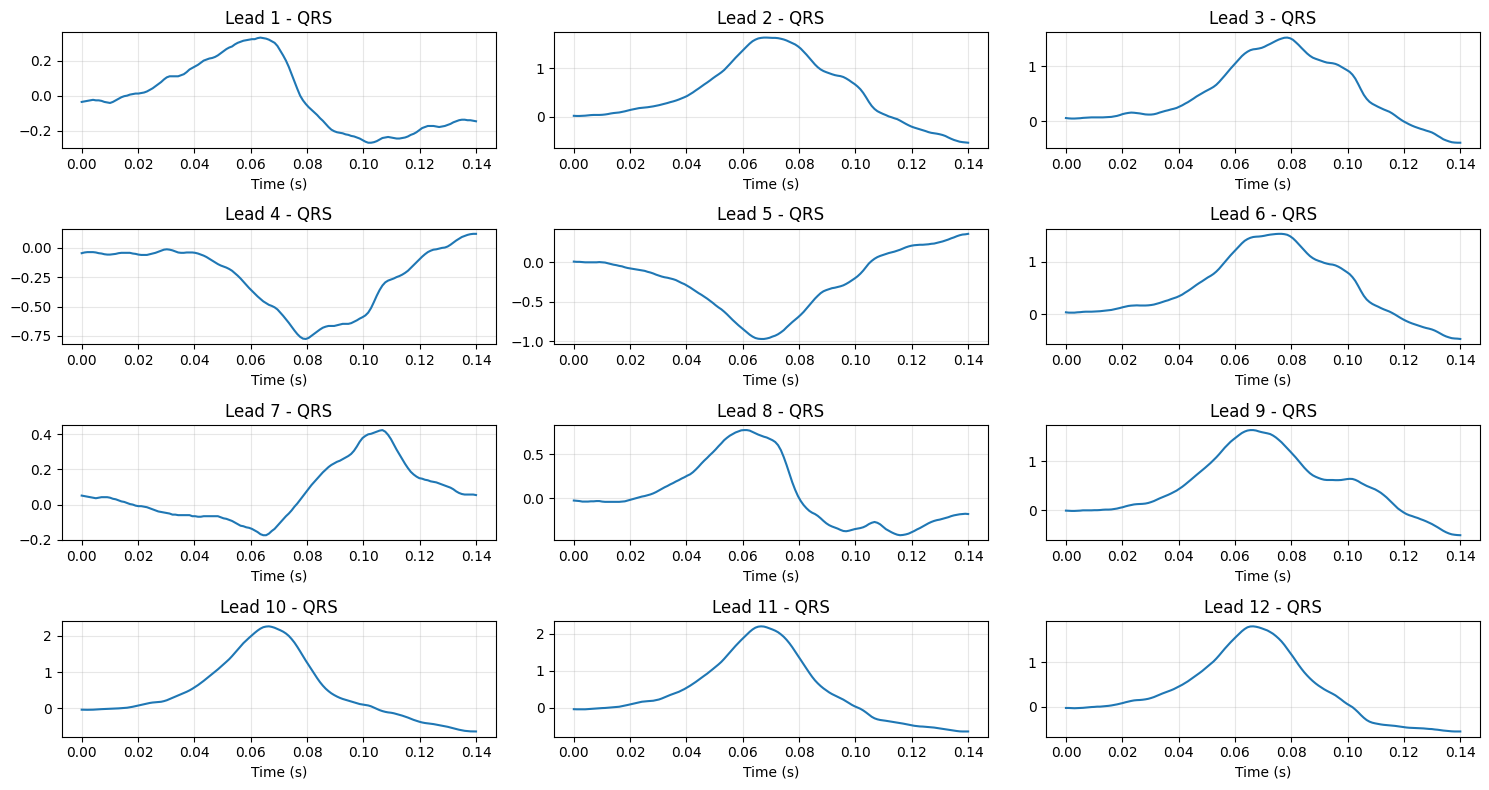

In [27]:
fig, ax = plt.subplots(4, 3, figsize=(15, 8))
ax = ax.flatten()

# Time axis for QRS segment
x_qrs = np.linspace(0, qrs.shape[0]/fs, qrs.shape[0])

# Plot all 12 leads with QRS segment
for i in range(qrs.shape[1]):
    ax[i].plot(x_qrs, qrs[:, i])
    ax[i].set_title(f'Lead {i+1} - QRS')
    ax[i].set_xlabel('Time (s)')
    ax[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# CELDA COMÚN: PREPROCESADO TEKNON-FOCUSED PARA LAS 3 TAREAS
# Ejecutar una vez antes de las tres celdas de entrenamiento.
# ============================================================

import os
import io
import pickle
import warnings
import contextlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal as scipy_signal
from scipy.stats import rankdata

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
)
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
FS_TEKNON = 1000
QRS_N_SAMPLES = 120
BEAT_INDEX = -1
USE_QRS_CACHE = True
COMMON_QRS_CACHE_PATH = f"qrs_teknon_features_common_{QRS_N_SAMPLES}_samples.pkl"
CLINICAL_FEATURES = ["Age", "PVC_transition", "Sex", "HTA"]
QRS_LEAD_NAMES = [
    "I", "II", "III", "aVR", "aVL", "aVF",
    "V1", "V2", "V3", "V4", "V5", "V6",
]
MAT_LEADS = QRS_LEAD_NAMES.copy()

TEKNON_LEADS = list(StandardHeader) if "StandardHeader" in globals() else [
    "I", "II", "III", "AVR", "AVL", "AVF",
    "V1", "V2", "V3", "V4", "V5", "V6",
]

QRS_REDUCER_CONFIG = {
    "n_leads": 12,
    "samples_per_lead": QRS_N_SAMPLES,
    "waveform_bins_per_lead": 24,
    "max_selected_qrs_features": 48,
    "min_selected_qrs_features": 18,
    "redundancy_threshold": 0.96,
}


# ------------------------------------------------------------
# 1. VALIDACIÓN Y EXTRACCIÓN QRS DE TEKNON
# ------------------------------------------------------------

def validate_requirements(include_mat=False):
    required = ["teknon", "train_set_ot", "models_ECG", "predict_ecg"]

    if include_mat:
        required.append("load_dataset")

    missing = [
        name
        for name in required
        if name not in globals()
    ]

    if missing:
        raise NameError(
            f"Faltan variables de celdas anteriores: {missing}"
        )

    if "SOO_std" not in train_set_ot.columns:
        raise KeyError(
            "train_set_ot no contiene SOO_std. "
            "Ejecuta antes la estandarización de SOO."
        )


def check_official_test_is_untouched(model_df):
    if "test_set" not in globals():
        print("[WARN] No se ha encontrado test_set oficial.")
        return

    overlap = model_df.index.intersection(
        test_set.index
    )

    if len(overlap):
        raise RuntimeError(
            f"Hay {len(overlap)} pacientes del test_set oficial "
            "dentro del conjunto de desarrollo."
        )

    print(
        "Official final Teknon test_set detected and kept untouched."
    )


def get_patient_lead_signal(
    teknon_dict,
    lead,
    patient_idx
):
    data = teknon_dict[
        lead
    ]

    attempts = [
        lambda x: x[
            patient_idx
        ],
        lambda x: x[
            0
        ][
            patient_idx
        ],
        lambda x: x[
            patient_idx
        ][
            0
        ],
        lambda x: x[
            0,
            patient_idx
        ],
        lambda x: x[
            patient_idx,
            0
        ],
    ]

    last_error = None

    for attempt in attempts:
        try:
            sig = np.asarray(
                attempt(
                    data
                )
            ).squeeze()

            if (
                sig.ndim > 0
                and sig.size >= 5
            ):
                return sig.astype(
                    float
                )

        except Exception as exc:
            last_error = exc

    raise ValueError(
        f"No se pudo extraer {lead} para el paciente "
        f"{patient_idx}: {last_error}"
    )


def build_patient_ecg(
    teknon_dict,
    patient_idx
):
    lead_signals = [
        get_patient_lead_signal(
            teknon_dict,
            lead,
            patient_idx
        )
        for lead in TEKNON_LEADS
    ]

    min_len = min(
        len(
            sig
        )
        for sig in lead_signals
    )

    return np.column_stack([
        sig[
            :min_len
        ]
        for sig in lead_signals
    ])


def extract_qrs_from_segmentation(
    ecg_signals,
    segmentation,
    beat_index=BEAT_INDEX
):
    if (
        segmentation is None
        or np.asarray(
            segmentation
        ).size == 0
    ):
        return None

    segmentation = np.asarray(
        segmentation
    )

    if (
        segmentation.ndim != 2
        or segmentation.shape[
            0
        ] < 2
    ):
        return None

    min_len = min(
        ecg_signals.shape[
            0
        ],
        segmentation.shape[
            1
        ]
    )

    ecg_signals = ecg_signals[
        :min_len
    ]

    segmentation = segmentation[
        :,
        :min_len
    ]

    mask = (
        segmentation[
            1
        ]
        == 1
    )

    if not np.any(
        mask
    ):
        return None

    diff = np.diff(
        mask.astype(
            int
        )
    )

    starts = list(
        np.where(
            diff == 1
        )[
            0
        ]
        + 1
    )

    ends = list(
        np.where(
            diff == -1
        )[
            0
        ]
        + 1
    )

    if mask[
        0
    ]:
        starts = [
            0
        ] + starts

    if mask[
        -1
    ]:
        ends = ends + [
            len(
                mask
            )
        ]

    n_qrs = min(
        len(
            starts
        ),
        len(
            ends
        )
    )

    if n_qrs == 0:
        return None

    starts = np.asarray(
        starts[
            :n_qrs
        ]
    )

    ends = np.asarray(
        ends[
            :n_qrs
        ]
    )

    valid = (
        ends
        > starts
    )

    starts = starts[
        valid
    ]

    ends = ends[
        valid
    ]

    if len(
        starts
    ) == 0:
        return None

    if beat_index >= len(
        starts
    ):
        beat_index = -1

    qrs = ecg_signals[
        starts[
            beat_index
        ]:
        ends[
            beat_index
        ]
    ]

    return (
        qrs
        if qrs.size
        else None
    )


def qrs_to_fixed_raw_features(
    ecg_signals
):
    segmentation = predict_ecg(
        ecg_signals,
        FS_TEKNON,
        models_ECG,
        normalize=True,
        filter=True
    )

    qrs = extract_qrs_from_segmentation(
        ecg_signals,
        segmentation
    )

    if (
        qrs is None
        or qrs.ndim != 2
    ):
        return None

    qrs = scipy_signal.resample(
        qrs,
        QRS_N_SAMPLES,
        axis=0
    )

    qrs = np.nan_to_num(
        qrs,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    max_abs = np.max(
        np.abs(
            qrs
        )
    )

    if max_abs > 0:
        qrs = (
            qrs
            / max_abs
        )

    # Mantenemos el formato original de las cachés anteriores.
    return qrs.reshape(
        -1
    )


def compute_teknon_qrs_features(
    df
):
    rows = []
    valid_indices = []
    failed_indices = []

    for patient_idx in df.index:
        try:
            ecg_signals = build_patient_ecg(
                teknon,
                patient_idx
            )

            features = qrs_to_fixed_raw_features(
                ecg_signals
            )

            if features is None:
                failed_indices.append(
                    patient_idx
                )

            else:
                rows.append(
                    features
                )

                valid_indices.append(
                    patient_idx
                )

        except Exception:
            failed_indices.append(
                patient_idx
            )

    if not rows:
        raise RuntimeError(
            "No se ha podido extraer ningún QRS de Teknon."
        )

    qrs_df = pd.DataFrame(
        rows,
        index=valid_indices,
        columns=[
            f"qrs_{i}"
            for i in range(
                len(
                    rows[
                        0
                    ]
                )
            )
        ],
    )

    return (
        qrs_df,
        failed_indices
    )


def load_cache(
    path
):
    if not os.path.exists(
        path
    ):
        return pd.DataFrame()

    try:
        with open(
            path,
            "rb"
        ) as file:
            cached = pickle.load(
                file
            )

        if isinstance(
            cached,
            pd.DataFrame
        ):
            return cached

    except Exception:
        pass

    return pd.DataFrame()


def load_or_compute_teknon_qrs(
    model_df,
    task_name
):
    legacy_path = (
        f"qrs_teknon_features_"
        f"{task_name}_"
        f"{QRS_N_SAMPLES}_samples.pkl"
    )

    cache_candidates = [
        load_cache(
            COMMON_QRS_CACHE_PATH
        ),
        load_cache(
            legacy_path
        ),
    ]

    cache_candidates = [
        df
        for df in cache_candidates
        if not df.empty
    ]

    if cache_candidates:
        cached = pd.concat(
            cache_candidates,
            axis=0
        )

        cached = cached.loc[
            ~cached.index.duplicated(
                keep="first"
            )
        ]

    else:
        cached = pd.DataFrame()

    missing = [
        idx
        for idx in model_df.index
        if idx not in cached.index
    ]

    failed = []

    if missing:
        new_features, failed = (
            compute_teknon_qrs_features(
                model_df.loc[
                    missing
                ]
            )
        )

        cached = pd.concat(
            [
                cached,
                new_features
            ],
            axis=0
        )

        cached = cached.loc[
            ~cached.index.duplicated(
                keep="last"
            )
        ]

        if USE_QRS_CACHE:
            with open(
                COMMON_QRS_CACHE_PATH,
                "wb"
            ) as file:
                pickle.dump(
                    cached,
                    file
                )

    valid = [
        idx
        for idx in model_df.index
        if idx in cached.index
    ]

    if not valid:
        raise RuntimeError(
            "No quedan pacientes válidos de Teknon "
            "tras extraer los QRS."
        )

    if failed:
        print(
            "[WARN] Falló la extracción QRS para "
            f"{len(failed)} pacientes Teknon."
        )

    return (
        model_df.loc[
            valid
        ].copy(),
        cached.loc[
            valid
        ].copy()
    )


def build_teknon_pool(
    model_df,
    qrs_df
):
    columns = (
        CLINICAL_FEATURES
        + [
            "target"
        ]
    )

    if "SOO_std" in model_df.columns:
        columns.append(
            "SOO_std"
        )

    meta = model_df[
        columns
    ].copy()

    meta[
        "source"
    ] = "Teknon"

    meta[
        "sample_id"
    ] = [
        f"Teknon_{idx}"
        for idx in meta.index
    ]

    qrs_df = qrs_df.copy()

    qrs_df.index = meta[
        "sample_id"
    ].values

    meta.index = meta[
        "sample_id"
    ].values

    return (
        meta,
        qrs_df
    )


# ------------------------------------------------------------
# 2. HOLDOUT TEKNON Y POOLS EXTERNOS BINARIOS
# ------------------------------------------------------------

def reserve_teknon_holdout(
    meta,
    qrs,
    class_ids,
    fraction=0.20,
    random_state=RANDOM_STATE
):
    """
    Reserva un holdout Teknon-only independiente.

    Reglas:
    - >= 3 pacientes únicos: se separan train y holdout.
    - 1 o 2 pacientes únicos: se conservan solo en train.
    - 0 pacientes: se detiene el entrenamiento de esa tarea.
    """
    rng = np.random.default_rng(
        random_state
    )

    train = []
    holdout = []

    print(
        "\nTeknon-only holdout split:"
    )

    for cls in class_ids:
        indices = pd.unique(
            meta[
                meta[
                    "target"
                ]
                == cls
            ].index
        )

        n_unique = len(
            indices
        )

        if n_unique == 0:
            raise ValueError(
                f"La clase {cls} no tiene pacientes Teknon válidos "
                "después del filtrado QRS. "
                "No es posible entrenar esta clase."
            )

        if n_unique < 3:
            train.extend(
                indices.tolist()
            )

            print(
                f"[WARN] Clase {cls}: solo hay "
                f"{n_unique} paciente(s) Teknon único(s). "
                "Se mantienen exclusivamente en train y se excluyen "
                "del holdout Teknon-only para evitar leakage."
            )

            continue

        n_holdout = min(
            max(
                1,
                int(
                    round(
                        n_unique
                        * fraction
                    )
                )
            ),
            n_unique - 2
        )

        sampled_holdout = rng.choice(
            indices,
            size=n_holdout,
            replace=False
        )

        sampled_holdout_set = set(
            sampled_holdout.tolist()
        )

        sampled_train = [
            idx
            for idx in indices
            if idx not in sampled_holdout_set
        ]

        train.extend(
            sampled_train
        )

        holdout.extend(
            sampled_holdout.tolist()
        )

        print(
            f"Clase {cls}: "
            f"{len(sampled_train)} paciente(s) en train + "
            f"{len(sampled_holdout)} paciente(s) en holdout."
        )

    if not train:
        raise RuntimeError(
            "No quedan pacientes Teknon disponibles para entrenar."
        )

    return (
        meta.loc[
            train
        ].copy(),
        qrs.loc[
            train
        ].copy(),
        meta.loc[
            holdout
        ].copy(),
        qrs.loc[
            holdout
        ].copy(),
    )


def load_binary_mat_pool(
    path,
    data_key,
    source_name
):
    with contextlib.redirect_stdout(
        io.StringIO()
    ):
        X, y = load_dataset(
            path,
            QRS_N_SAMPLES,
            data_key,
            MAT_LEADS,
            False,
            False,
            RANDOM_STATE,
        )

    X = np.asarray(
        X,
        dtype=float
    )

    y = np.asarray(
        y
    ).astype(
        int
    )

    # Convención común del notebook:
    # RVOT = 0 y LVOT = 1.
    y = np.where(
        y == 1,
        0,
        1
    )

    meta = pd.DataFrame({
        "Age": np.nan,
        "PVC_transition": np.nan,
        "Sex": np.nan,
        "HTA": np.nan,
        "target": y,
        "source": source_name,
        "sample_id": [
            f"{source_name}_{i}"
            for i in range(
                len(
                    y
                )
            )
        ],
    })

    qrs = pd.DataFrame(
        X,
        columns=[
            f"qrs_{i}"
            for i in range(
                X.shape[
                    1
                ]
            )
        ]
    )

    meta.index = meta[
        "sample_id"
    ].values

    qrs.index = meta.index

    return (
        meta,
        qrs
    )


def clean_pool(
    meta,
    qrs
):
    meta = meta.loc[
        qrs.index
    ].copy()

    qrs = qrs.copy()

    meta[
        "Age"
    ] = pd.to_numeric(
        meta[
            "Age"
        ],
        errors="coerce"
    )

    for col in [
        "PVC_transition",
        "Sex",
        "HTA"
    ]:
        non_null = meta[
            col
        ].notna()

        meta.loc[
            non_null,
            col
        ] = meta.loc[
            non_null,
            col
        ].astype(
            str
        )

    return (
        meta,
        qrs.loc[
            meta.index
        ].copy()
    )


# ------------------------------------------------------------
# 3. BALANCEO SIN PACIENTES REPETIDOS ENTRE TRAIN Y TEST
# ------------------------------------------------------------

def create_balanced_dataset(
    meta,
    qrs,
    dataset_id,
    class_ids,
    n_per_class,
    test_size=0.20,
    random_state=RANDOM_STATE,
):
    """
    Crea un dataset balanceado evitando compartir pacientes originales
    entre train y test interno.

    Reglas:
    - >= 2 pacientes únicos: primero se separan train y test y después
      se aplica oversampling dentro de cada subconjunto.
    - 1 paciente único: se utiliza solo en train mediante oversampling.
    - 0 pacientes: se detiene el entrenamiento de esa tarea.
    """
    rng = np.random.default_rng(
        random_state
        + dataset_id
    )

    train_original = []
    test_original = []

    n_test = max(
        1,
        int(
            round(
                n_per_class
                * test_size
            )
        )
    )

    n_train = (
        n_per_class
        - n_test
    )

    print(
        "\nInternal balanced split:"
    )

    for cls in class_ids:
        indices = np.unique(
            meta[
                meta[
                    "target"
                ]
                == cls
            ].index.to_numpy()
        )

        n_unique = len(
            indices
        )

        if n_unique == 0:
            raise ValueError(
                f"La clase {cls} no tiene pacientes originales "
                "disponibles en el train pool. "
                "No es posible entrenar esta clase."
            )

        if n_unique == 1:
            sampled_train = rng.choice(
                indices,
                size=n_train,
                replace=True
            )

            train_original.extend(
                sampled_train.tolist()
            )

            print(
                f"[WARN] Clase {cls}: solo hay 1 paciente original. "
                f"Se utiliza exclusivamente en train mediante "
                f"oversampling ({n_train} filas) y se excluye "
                "del test interno para evitar leakage."
            )

            continue

        n_unique_test = min(
            max(
                1,
                int(
                    round(
                        n_unique
                        * test_size
                    )
                )
            ),
            n_unique - 1,
        )

        test_pool = rng.choice(
            indices,
            size=n_unique_test,
            replace=False
        )

        test_set = set(
            test_pool.tolist()
        )

        train_pool = np.asarray([
            idx
            for idx in indices
            if idx not in test_set
        ])

        sampled_train = rng.choice(
            train_pool,
            size=n_train,
            replace=(
                len(
                    train_pool
                )
                < n_train
            ),
        )

        sampled_test = rng.choice(
            test_pool,
            size=n_test,
            replace=(
                len(
                    test_pool
                )
                < n_test
            ),
        )

        train_original.extend(
            sampled_train.tolist()
        )

        test_original.extend(
            sampled_test.tolist()
        )

        print(
            f"Clase {cls}: "
            f"{len(train_pool)} paciente(s) único(s) en train + "
            f"{len(test_pool)} paciente(s) único(s) en test."
        )

    if not train_original:
        raise RuntimeError(
            "No se ha podido crear el conjunto de entrenamiento."
        )

    if not test_original:
        raise RuntimeError(
            "No se ha podido crear un test interno independiente. "
            "Se necesitan más pacientes únicos."
        )

    rng.shuffle(
        train_original
    )

    rng.shuffle(
        test_original
    )

    all_original = (
        train_original
        + test_original
    )

    balanced_meta = meta.loc[
        all_original
    ].copy()

    balanced_qrs = qrs.loc[
        all_original
    ].copy()

    new_index = [
        f"D{dataset_id}_{i}"
        for i in range(
            len(
                balanced_meta
            )
        )
    ]

    balanced_meta.index = new_index
    balanced_qrs.index = new_index

    train_idx = new_index[
        :len(
            train_original
        )
    ]

    test_idx = new_index[
        len(
            train_original
        ):
    ]

    leakage = set(
        balanced_meta.loc[
            train_idx,
            "sample_id"
        ]
    ).intersection(
        set(
            balanced_meta.loc[
                test_idx,
                "sample_id"
            ]
        )
    )

    if leakage:
        raise RuntimeError(
            f"Leakage detectado: {len(leakage)} pacientes originales "
            "aparecen simultáneamente en train y test."
        )

    print(
        "Leakage check passed: "
        "ningún paciente original aparece a la vez en train y test."
    )

    return (
        balanced_meta,
        balanced_qrs,
        train_idx,
        test_idx
    )


# ------------------------------------------------------------
# 4. MORFOLOGÍA QRS Y SELECCIÓN DE LAS MEJORES FEATURES
# ------------------------------------------------------------

def normalize_rows(
    X
):
    X = np.nan_to_num(
        np.asarray(
            X,
            dtype=float
        ),
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    scale = np.max(
        np.abs(
            X
        ),
        axis=1,
        keepdims=True
    )

    scale[
        scale == 0
    ] = 1.0

    return (
        X
        / scale
    )


def to_common_lead_major_layout(
    meta,
    qrs
):
    n_leads = QRS_REDUCER_CONFIG[
        "n_leads"
    ]

    n_samples = QRS_REDUCER_CONFIG[
        "samples_per_lead"
    ]

    expected_features = (
        n_leads
        * n_samples
    )

    X = qrs.to_numpy(
        dtype=float,
        copy=True
    )

    if X.shape[
        1
    ] != expected_features:
        raise ValueError(
            f"Se esperaban {expected_features} valores QRS "
            f"y se han recibido {X.shape[1]}."
        )

    teknon_mask = (
        meta.loc[
            qrs.index,
            "source"
        ]
        .astype(
            str
        )
        .str.lower()
        .eq(
            "teknon"
        )
        .to_numpy()
    )

    if np.any(
        teknon_mask
    ):
        # Teknon estaba aplanado intercalando derivaciones
        # por instante temporal.
        # Lo convertimos a bloques de derivación como en
        # los datasets externos .mat.
        X_teknon = X[
            teknon_mask
        ].reshape(
            -1,
            n_samples,
            n_leads
        )

        X[
            teknon_mask
        ] = X_teknon.transpose(
            0,
            2,
            1
        ).reshape(
            -1,
            expected_features
        )

    return normalize_rows(
        X
    )


def linear_slope(
    values
):
    x = np.arange(
        values.shape[
            1
        ],
        dtype=float
    )

    x = (
        x
        - x.mean()
    )

    return (
        np.sum(
            (
                values
                - values.mean(
                    axis=1,
                    keepdims=True
                )
            )
            * x,
            axis=1
        )
        / np.sum(
            x ** 2
        )
    )


def build_qrs_candidates(
    meta,
    qrs_df
):
    n_leads = QRS_REDUCER_CONFIG[
        "n_leads"
    ]

    n_samples = QRS_REDUCER_CONFIG[
        "samples_per_lead"
    ]

    n_bins = QRS_REDUCER_CONFIG[
        "waveform_bins_per_lead"
    ]

    qrs = to_common_lead_major_layout(
        meta,
        qrs_df
    ).reshape(
        -1,
        n_leads,
        n_samples
    )

    reduced = qrs.reshape(
        -1,
        n_leads,
        n_bins,
        n_samples
        // n_bins
    ).mean(
        axis=3
    )

    parts = [
        reduced.reshape(
            len(
                qrs
            ),
            -1
        )
    ]

    names = [
        f"wave_{lead}_bin_{i:02d}"
        for lead in QRS_LEAD_NAMES
        for i in range(
            n_bins
        )
    ]

    eps = 1e-8

    slopes = np.diff(
        qrs,
        axis=2
    )

    qrs_abs = np.abs(
        qrs
    )

    qrs_max = np.max(
        qrs,
        axis=2
    )

    qrs_min = np.min(
        qrs,
        axis=2
    )

    morphology = {
        "mean": np.mean(
            qrs,
            axis=2
        ),

        "std": np.std(
            qrs,
            axis=2
        ),

        "maximum": qrs_max,

        "minimum": qrs_min,

        "peak_to_peak": (
            qrs_max
            - qrs_min
        ),

        "rms": np.sqrt(
            np.mean(
                qrs ** 2,
                axis=2
            )
        ),

        "absolute_area": np.mean(
            qrs_abs,
            axis=2
        ),

        "signed_area": np.mean(
            qrs,
            axis=2
        ),

        "r_s_ratio": (
            qrs_max
            / (
                np.abs(
                    qrs_min
                )
                + eps
            )
        ),

        "r_minus_s": (
            qrs_max
            - np.abs(
                qrs_min
            )
        ),

        "r_peak_position": (
            np.argmax(
                qrs,
                axis=2
            )
            / (
                n_samples
                - 1
            )
        ),

        "s_peak_position": (
            np.argmin(
                qrs,
                axis=2
            )
            / (
                n_samples
                - 1
            )
        ),

        "max_up_slope": np.max(
            slopes,
            axis=2
        ),

        "max_down_slope": np.min(
            slopes,
            axis=2
        ),

        "zero_crossing_rate": (
            np.sum(
                np.diff(
                    np.signbit(
                        qrs
                    ),
                    axis=2
                )
                != 0,
                axis=2
            )
            / (
                n_samples
                - 1
            )
        ),

        "early_absolute_area": np.mean(
            qrs_abs[
                :,
                :,
                :n_samples
                // 3
            ],
            axis=2
        ),

        "middle_absolute_area": np.mean(
            qrs_abs[
                :,
                :,
                n_samples
                // 3:
                2
                * n_samples
                // 3
            ],
            axis=2
        ),

        "late_absolute_area": np.mean(
            qrs_abs[
                :,
                :,
                2
                * n_samples
                // 3:
            ],
            axis=2
        ),
    }

    for metric, values in morphology.items():
        parts.append(
            values
        )

        names.extend([
            f"{metric}_{lead}"
            for lead in QRS_LEAD_NAMES
        ])

    precordial = slice(
        6,
        12
    )

    inferior = [
        1,
        2,
        5
    ]

    lateral = [
        0,
        4
    ]

    rs_precordial = morphology[
        "r_s_ratio"
    ][
        :,
        precordial
    ]

    transition = np.where(
        (
            rs_precordial
            >= 1
        ).any(
            axis=1
        ),
        (
            rs_precordial
            >= 1
        ).argmax(
            axis=1
        ),
        6
    ) / 6.0

    global_features = np.column_stack([
        transition,

        linear_slope(
            qrs_max[
                :,
                precordial
            ]
        ),

        linear_slope(
            np.abs(
                qrs_min[
                    :,
                    precordial
                ]
            )
        ),

        linear_slope(
            morphology[
                "r_minus_s"
            ][
                :,
                precordial
            ]
        ),

        np.mean(
            morphology[
                "signed_area"
            ][
                :,
                inferior
            ],
            axis=1
        ),

        np.mean(
            morphology[
                "signed_area"
            ][
                :,
                lateral
            ],
            axis=1
        ),

        np.mean(
            qrs_max[
                :,
                inferior
            ],
            axis=1
        ),

        np.mean(
            np.abs(
                qrs_min[
                    :,
                    inferior
                ]
            ),
            axis=1
        ),

        (
            morphology[
                "r_minus_s"
            ][
                :,
                11
            ]
            - morphology[
                "r_minus_s"
            ][
                :,
                6
            ]
        ),
    ])

    parts.append(
        global_features
    )

    names.extend([
        "global_precordial_transition",
        "global_r_progression_slope",
        "global_s_progression_slope",
        "global_dominance_progression_slope",
        "global_inferior_signed_area",
        "global_lateral_signed_area",
        "global_inferior_r_amplitude",
        "global_inferior_s_amplitude",
        "global_v6_minus_v1_dominance",
    ])

    candidate_matrix = np.hstack(
        parts
    )

    candidate_matrix = np.nan_to_num(
        candidate_matrix,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    return (
        candidate_matrix,
        np.asarray(
            names,
            dtype=object
        )
    )


def rank_score(
    values
):
    values = np.asarray(
        values
    )

    if len(
        values
    ) <= 1:
        return np.ones_like(
            values,
            dtype=float
        )

    ranks = rankdata(
        -values,
        method="average"
    )

    return (
        1
        - (
            ranks
            - 1
        )
        / (
            len(
                values
            )
            - 1
        )
    )


def selector_fit_indices(
    meta,
    train_idx
):
    train_meta = meta.loc[
        list(
            train_idx
        )
    ].copy()

    train_meta = train_meta.loc[
        ~train_meta[
            "sample_id"
        ].astype(
            str
        ).duplicated(
            keep="first"
        )
    ]

    all_classes = set(
        train_meta[
            "target"
        ].astype(
            int
        ).unique()
    )

    teknon_meta = train_meta[
        train_meta[
            "source"
        ].astype(
            str
        ).str.lower().eq(
            "teknon"
        )
    ]

    teknon_classes = set(
        teknon_meta[
            "target"
        ].astype(
            int
        ).unique()
    )

    if (
        len(
            teknon_meta
        )
        >= max(
            18,
            3
            * len(
                all_classes
            )
        )
        and teknon_classes
        == all_classes
    ):
        return (
            teknon_meta.index.to_list(),
            "unique Teknon training patients"
        )

    return (
        train_meta.index.to_list(),
        "all unique training patients (fallback)"
    )


def fit_qrs_selector(
    meta,
    qrs,
    train_idx,
    random_state
):
    fit_idx, fit_scope = selector_fit_indices(
        meta,
        train_idx
    )

    X, names = build_qrs_candidates(
        meta.loc[
            fit_idx
        ],
        qrs.loc[
            fit_idx
        ]
    )

    y = meta.loc[
        fit_idx,
        "target"
    ].astype(
        int
    ).to_numpy()

    valid = (
        np.var(
            X,
            axis=0
        )
        > 1e-10
    )

    X_valid = X[
        :,
        valid
    ]

    original_idx = np.flatnonzero(
        valid
    )

    if X_valid.shape[
        1
    ] == 0:
        raise RuntimeError(
            "Todas las features QRS candidatas son constantes."
        )

    n_fit = len(
        X_valid
    )

    min_k = min(
        QRS_REDUCER_CONFIG[
            "min_selected_qrs_features"
        ],
        max(
            1,
            n_fit
            - 1
        ),
    )

    k = min(
        QRS_REDUCER_CONFIG[
            "max_selected_qrs_features"
        ],
        X_valid.shape[
            1
        ],
        max(
            8,
            min_k,
            n_fit
            // 2
        ),
    )

    forest = ExtraTreesClassifier(
        n_estimators=500,
        min_samples_leaf=2,
        class_weight="balanced",
        max_features="sqrt",
        random_state=random_state,
        n_jobs=-1,
    )

    forest.fit(
        X_valid,
        y
    )

    try:
        mi = mutual_info_classif(
            X_valid,
            y,
            random_state=random_state
        )

    except ValueError:
        mi = np.zeros(
            X_valid.shape[
                1
            ]
        )

    combined_score = (
        0.65
        * rank_score(
            forest.feature_importances_
        )
        + 0.35
        * rank_score(
            mi
        )
    )

    ranking = np.argsort(
        combined_score
    )[
        ::-1
    ]

    corr = np.corrcoef(
        X_valid,
        rowvar=False
    )

    corr = np.nan_to_num(
        corr,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    chosen = []

    for idx in ranking:
        if (
            not chosen
            or not np.any(
                np.abs(
                    corr[
                        idx,
                        chosen
                    ]
                )
                >= QRS_REDUCER_CONFIG[
                    "redundancy_threshold"
                ]
            )
        ):
            chosen.append(
                idx
            )

        if len(
            chosen
        ) >= k:
            break

    for idx in ranking:
        if len(
            chosen
        ) >= k:
            break

        if idx not in chosen:
            chosen.append(
                idx
            )

    selected = original_idx[
        np.asarray(
            chosen,
            dtype=int
        )
    ]

    selected_names = names[
        selected
    ]

    print(
        "QRS feature reduction: "
        f"1440 raw values -> "
        f"{X.shape[1]} candidates -> "
        f"{len(selected)} selected QRS features."
    )

    print(
        f"Ranking fitted on {len(fit_idx)} {fit_scope}."
    )

    print(
        "Top selected QRS variables:",
        ", ".join(
            selected_names[
                :12
            ]
        )
    )

    return {
        "selected_indices": selected,
        "selected_feature_names": selected_names.tolist(),
        "fit_scope": fit_scope,
    }


def transform_qrs(
    meta,
    qrs,
    selector
):
    X, _ = build_qrs_candidates(
        meta,
        qrs
    )

    return X[
        :,
        np.asarray(
            selector[
                "selected_indices"
            ],
            dtype=int
        )
    ]


# ------------------------------------------------------------
# 5. VARIABLES CLÍNICAS, MODELOS Y EVALUACIÓN
# ------------------------------------------------------------

def one_hot_encoder():
    try:
        return OneHotEncoder(
            drop="first",
            sparse_output=False,
            handle_unknown="ignore"
        )

    except TypeError:
        return OneHotEncoder(
            drop="first",
            sparse=False,
            handle_unknown="ignore"
        )


def clinical_preprocessor():
    return ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline([
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="constant",
                            fill_value=-1
                        )
                    ),
                    (
                        "scaler",
                        StandardScaler()
                    ),
                ]),
                [
                    "Age"
                ],
            ),

            (
                "ord",
                Pipeline([
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="constant",
                            fill_value="Unknown"
                        )
                    ),
                    (
                        "encoder",
                        OrdinalEncoder(
                            categories=[[
                                "Unknown",
                                "V1",
                                "V2",
                                "V3",
                                "V4",
                                "V5",
                                "V6"
                            ]],
                            handle_unknown="use_encoded_value",
                            unknown_value=-1,
                        ),
                    ),
                ]),
                [
                    "PVC_transition"
                ],
            ),

            (
                "bin",
                Pipeline([
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="constant",
                            fill_value="Unknown"
                        )
                    ),
                    (
                        "encoder",
                        one_hot_encoder()
                    ),
                ]),
                [
                    "Sex",
                    "HTA"
                ],
            ),
        ],
        remainder="drop",
    )


def build_final_features(
    meta,
    qrs,
    train_idx,
    test_idx,
    random_state,
    use_clinical=True
):
    selector = fit_qrs_selector(
        meta,
        qrs,
        train_idx,
        random_state
    )

    X_train_qrs = transform_qrs(
        meta.loc[
            train_idx
        ],
        qrs.loc[
            train_idx
        ],
        selector
    )

    X_test_qrs = transform_qrs(
        meta.loc[
            test_idx
        ],
        qrs.loc[
            test_idx
        ],
        selector
    )

    if use_clinical:
        prep = clinical_preprocessor()
        X_train_clin = prep.fit_transform(
            meta.loc[train_idx, CLINICAL_FEATURES].copy()
        )
        X_test_clin = prep.transform(
            meta.loc[test_idx, CLINICAL_FEATURES].copy()
        )
        X_train = np.hstack([X_train_qrs, X_train_clin])
        X_test  = np.hstack([X_test_qrs,  X_test_clin])
    else:
        prep    = None
        X_train = X_train_qrs
        X_test  = X_test_qrs

    n_clin = X_train_clin.shape[1] if use_clinical else 0
    print(
    f"Final model matrix: "
    f"{X_train.shape[1]} variables "
    f"({X_train_qrs.shape[1]} QRS "
    f"+ {n_clin} clinical)."
    )

    y_train = meta.loc[
        train_idx,
        "target"
    ].astype(
        int
    ).to_numpy()

    y_test = meta.loc[
        test_idx,
        "target"
    ].astype(
        int
    ).to_numpy()

    return (
        X_train,
        X_test,
        y_train,
        y_test,
        prep,
        selector
    )


def build_holdout_features(
    meta, qrs, prep, selector
):
    X_qrs = transform_qrs(meta, qrs, selector)

    if prep is not None and CLINICAL_FEATURES:
        X_clin = prep.transform(
            meta[CLINICAL_FEATURES].copy()
        )
        X_final = np.hstack([X_qrs, X_clin])
    else:
        X_final = X_qrs

    y = meta[
        "target"
    ].astype(
        int
    ).to_numpy()

    return (
        X_final,
        y
    )


def get_models(
    random_state
):
    return {
        "Random Forest": RandomForestClassifier(
            n_estimators=500,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=random_state,
            n_jobs=-1,
        ),

        "Extra Trees": ExtraTreesClassifier(
            n_estimators=500,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=random_state,
            n_jobs=-1,
        ),

        "Logistic Regression": Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "clf",
                LogisticRegression(
                    max_iter=3000,
                    class_weight="balanced",
                    random_state=random_state,
                ),
            ),
        ]),

        "SVM RBF": Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "clf",
                SVC(
                    kernel="rbf",
                    C=1.0,
                    gamma="scale",
                    class_weight="balanced",
                    random_state=random_state,
                ),
            ),
        ]),

        "Gradient Boosting": GradientBoostingClassifier(
            random_state=random_state
        ),
    }

def evaluate_model_cv(model, X, y, cv_splits=5):
    """Run stratified cross-validation and return mean scores."""
    cv = StratifiedKFold(
        n_splits=cv_splits,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    cv_results = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=["accuracy", "balanced_accuracy"],
        n_jobs=-1,
        return_train_score=False,
    )

    return {
        "cv_accuracy": np.mean(cv_results["test_accuracy"]),
        "cv_balanced_accuracy": np.mean(cv_results["test_balanced_accuracy"]),
        "cv_accuracy_std": np.std(cv_results["test_accuracy"]),
        "cv_balanced_accuracy_std": np.std(cv_results["test_balanced_accuracy"]),
    }

def plot_cm(
    cm,
    labels,
    title
):
    fig, ax = plt.subplots(
        figsize=(
            max(
                6,
                len(
                    labels
                )
                + 1
            ),
            5
        )
    )

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels,
    ).plot(
        ax=ax,
        values_format="d",
        xticks_rotation=45,
    )

    plt.title(
        title
    )

    plt.tight_layout()
    plt.show()


def print_evaluation_coverage(
    y_true,
    class_ids,
    target_names,
    evaluation_name
):
    """
    Informa de las clases que no se pueden evaluar de forma independiente.
    Esas clases no se incluyen en las métricas del test correspondiente.
    """
    present_classes = set(
        np.asarray(
            y_true,
            dtype=int
        ).tolist()
    )

    excluded_classes = [
        cls
        for cls in class_ids
        if cls not in present_classes
    ]

    if excluded_classes:
        excluded_names = [
            (
                target_names[
                    cls
                ]
                if (
                    0
                    <= cls
                    < len(
                        target_names
                    )
                )
                else str(
                    cls
                )
            )
            for cls in excluded_classes
        ]

        print(
            f"[WARN] {evaluation_name}: "
            "estas clases no se pueden evaluar de forma "
            "independiente porque no tienen pacientes disponibles "
            "en este test: "
            + ", ".join(
                excluded_names
            )
        )

    else:
        print(
            f"{evaluation_name}: "
            "todas las clases están representadas."
        )

    return excluded_classes


def run_task(
    task_name,
    target_mapping,
    target_names,
    n_per_class,
    include_mat=False,
    n_datasets=5,
    test_size=0.20,
    use_clinical=True
):
    validate_requirements(
        include_mat
    )

    model_df = train_set_ot.copy()

    check_official_test_is_untouched(
        model_df
    )

    model_df[
        "SOO_std"
    ] = (
        model_df[
            "SOO_std"
        ]
        .astype(
            str
        )
        .str.strip()
    )

    model_df[
        "target"
    ] = model_df[
        "SOO_std"
    ].map(
        target_mapping
    )

    model_df = model_df.dropna(
        subset=[
            "target"
        ]
    ).copy()

    model_df[
        "target"
    ] = model_df[
        "target"
    ].astype(
        int
    )

    class_ids = list(
        range(
            len(
                target_names
            )
        )
    )

    print(
        "\nClass distribution before QRS filtering:"
    )

    print(
        model_df[
            "target"
        ].value_counts().sort_index()
    )

    model_df, qrs_teknon = (
        load_or_compute_teknon_qrs(
            model_df,
            task_name
        )
    )

    teknon_meta, qrs_teknon = (
        build_teknon_pool(
            model_df,
            qrs_teknon
        )
    )

    (
        train_meta,
        train_qrs,
        holdout_meta,
        holdout_qrs
    ) = reserve_teknon_holdout(
        teknon_meta,
        qrs_teknon,
        class_ids,
        test_size,
    )

    print(
        "\nTeknon-only development holdout reserved:"
    )

    print(
        holdout_meta[
            "target"
        ].value_counts().sort_index()
    )

    meta_parts = [
        train_meta
    ]

    qrs_parts = [
        train_qrs
    ]

    if include_mat:
        mat_configs = [
            (
                "data/QRS_CARTO2.mat",
                "QRS_CARTO",
                "QRS_CARTO2"
            ),
            (
                "data/QRS_Database2.mat",
                "QRS",
                "QRS_Database2"
            ),
        ]

        for (
            path,
            data_key,
            source
        ) in mat_configs:
            if os.path.exists(
                path
            ):
                meta_part, qrs_part = (
                    load_binary_mat_pool(
                        path,
                        data_key,
                        source
                    )
                )

                meta_parts.append(
                    meta_part
                )

                qrs_parts.append(
                    qrs_part
                )

            else:
                print(
                    f"[WARN] File not found: {path}"
                )

    full_meta, full_qrs = clean_pool(
        pd.concat(
            meta_parts,
            axis=0
        ),
        pd.concat(
            qrs_parts,
            axis=0
        ),
    )

    print(
        "\nTraining pool by source:"
    )

    print(
        full_meta[
            "source"
        ].value_counts()
    )

    print(
        "\nTraining pool by class:"
    )

    print(
        full_meta[
            "target"
        ].value_counts().sort_index()
    )

    balanced_datasets = {}
    trained_models = {}
    rows = []

    for dataset_id in range(
        1,
        n_datasets
        + 1
    ):
        print(
            "\n----- Balanced dataset "
            f"{dataset_id}/{n_datasets} -----"
        )

        (
            balanced_meta,
            balanced_qrs,
            train_idx,
            test_idx
        ) = create_balanced_dataset(
            full_meta,
            full_qrs,
            dataset_id,
            class_ids,
            n_per_class,
            test_size,
        )

        (
            X_train,
            X_test,
            y_train,
            y_test,
            prep,
            selector
        ) = build_final_features(
            balanced_meta,
            balanced_qrs,
            train_idx,
            test_idx,
            RANDOM_STATE
            + dataset_id,
            use_clinical=use_clinical
        )

        key = (
            f"dataset_{dataset_id}"
        )

        balanced_datasets[
            key
        ] = {
            "meta": balanced_meta,
            "qrs": balanced_qrs,
            "train_idx": train_idx,
            "test_idx": test_idx,
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test,
            "clinical_preprocessor": prep,
            "qrs_selector": selector,
        }

        models = get_models(
            RANDOM_STATE
            + dataset_id
        )

        for (
            model_name,
            model
        ) in models.items():
            cv_metrics = evaluate_model_cv(
                model,
                X_train,
                y_train,
                cv_splits=5,
            )
            model.fit(
                X_train,
                y_train
            )

            pred = model.predict(
                X_test
            )

            rows.append({
                "Dataset": f"Dataset {dataset_id}",
                "Model": model_name,
                "CV Accuracy": cv_metrics["cv_accuracy"],
                "CV Balanced Accuracy": cv_metrics["cv_balanced_accuracy"],
                "Accuracy": accuracy_score(
                    y_test,
                    pred
                ),
                "Balanced Accuracy": balanced_accuracy_score(
                    y_test,
                    pred
                ),
            })

            trained_models[
                (
                    key,
                    model_name
                )
            ] = model

    results = pd.DataFrame(
        rows
    )

    results[
        "Accuracy (%)"
    ] = (
        results[
            "Accuracy"
        ]
        * 100
    ).round(
        2
    )

    results[
        "Balanced Accuracy (%)"
    ] = (
        results[
            "Balanced Accuracy"
        ]
        * 100
    ).round(
        2
    )

    results["CV Accuracy (%)"] = (results["CV Accuracy"] * 100).round(2)
    results["CV Balanced Accuracy (%)"] = (results["CV Balanced Accuracy"] * 100).round(2)

    print(
        "\n=============================="
    )

    print(
        f"{task_name.upper()} - GLOBAL RESULTS"
    )

    print(
        "=============================="
    )

    display(
        results[[
            "Dataset",
            "Model",
            "Accuracy (%)",
            "Balanced Accuracy (%)",
            "CV Accuracy (%)",
            "CV Balanced Accuracy (%)"
        ]].sort_values(
            [
                "Dataset",
                "Balanced Accuracy (%)"
            ],
            ascending=[
                True,
                False
            ]
        )
    )

    best = results.sort_values(
        [
            "CV Balanced Accuracy",
            "CV Accuracy"
        ],
        ascending=False
    ).iloc[
        0
    ]

    key = (
        f"dataset_"
        f"{int(best['Dataset'].split()[-1])}"
    )

    best_data = balanced_datasets[
        key
    ]

    best_model = trained_models[
        (
            key,
            best[
                "Model"
            ]
        )
    ]

    pred_internal = best_model.predict(
        best_data[
            "X_test"
        ]
    )

    internal_excluded_classes = (
        print_evaluation_coverage(
            best_data[
                "y_test"
            ],
            class_ids,
            target_names,
            "Internal balanced test",
        )
    )

    cm_internal = confusion_matrix(
        best_data[
            "y_test"
        ],
        pred_internal,
        labels=class_ids,
    )

    print(
        "\nBest internal result: "
        f"{best['Dataset']} - "
        f"{best['Model']} | "
        f"Accuracy {best['Accuracy (%)']}% | "
        f"Balanced Accuracy {best['Balanced Accuracy (%)']}% |"
        f"CV Accuracy {best['CV Accuracy (%)']}% | "
        f"CV Balanced Accuracy {best['CV Balanced Accuracy (%)']}%"
    )

    plot_cm(
        cm_internal,
        target_names,
        (
            f"{task_name} - Internal Test - "
            f"{best['Dataset']} - "
            f"{best['Model']}"
        ),
    )

    print(
        "\n=============================="
    )

    print(
        f"{task_name.upper()} - "
        "BEST MODEL TEKNON-ONLY DEVELOPMENT HOLDOUT"
    )

    print(
        "=============================="
    )

    print(
        f"Dataset used for training: {best['Dataset']}"
    )

    print(
        f"Model: {best['Model']}"
    )

    if holdout_meta.empty:
        y_holdout = np.asarray(
            [],
            dtype=int
        )

        pred_holdout = np.asarray(
            [],
            dtype=int
        )

        holdout_acc = np.nan
        holdout_bal_acc = np.nan

        cm_holdout = np.zeros(
            (
                len(
                    class_ids
                ),
                len(
                    class_ids
                )
            ),
            dtype=int
        )

        holdout_excluded_classes = (
            class_ids.copy()
        )

        print(
            "[WARN] No se ha podido crear ningún holdout "
            "Teknon-only independiente. "
            "Todas las clases tienen menos de 3 pacientes únicos."
        )

        print(
            "Teknon-only holdout size: 0"
        )

        print(
            "Accuracy: not available"
        )

        print(
            "Balanced Accuracy: not available"
        )

    else:
        X_holdout, y_holdout = (
            build_holdout_features(
                holdout_meta,
                holdout_qrs,
                best_data[
                    "clinical_preprocessor"
                ],
                best_data[
                    "qrs_selector"
                ],
            )
        )

        pred_holdout = best_model.predict(
            X_holdout
        )

        holdout_acc = accuracy_score(
            y_holdout,
            pred_holdout
        )

        holdout_bal_acc = balanced_accuracy_score(
            y_holdout,
            pred_holdout
        )

        holdout_excluded_classes = (
            print_evaluation_coverage(
                y_holdout,
                class_ids,
                target_names,
                "Teknon-only development holdout",
            )
        )

        cm_holdout = confusion_matrix(
            y_holdout,
            pred_holdout,
            labels=class_ids,
        )

        print(
            f"Teknon-only holdout size: {len(y_holdout)}"
        )

        print(
            f"Accuracy: {holdout_acc * 100:.2f}%"
        )

        print(
            "Balanced Accuracy: "
            f"{holdout_bal_acc * 100:.2f}%"
        )

        plot_cm(
            cm_holdout,
            target_names,
            (
                f"{task_name} - "
                "Teknon-only Holdout - "
                f"{best['Dataset']} - "
                f"{best['Model']}"
            ),
        )

    return {
        "task_name": task_name,
        "target_names": target_names,
        "class_ids": class_ids,
        "full_meta_pool": full_meta,
        "full_qrs_pool": full_qrs,
        "teknon_holdout_test_meta": holdout_meta,
        "teknon_holdout_test_qrs": holdout_qrs,
        "balanced_datasets": balanced_datasets,
        "trained_models": trained_models,
        "results": results,
        "best_result": best,
        "best_model": best_model,
        "cm_internal": cm_internal,
        "cm_teknon_external": cm_holdout,
        "teknon_external_acc": holdout_acc,
        "teknon_external_bal_acc": holdout_bal_acc,
        "internal_excluded_classes": internal_excluded_classes,
        "teknon_external_excluded_classes": holdout_excluded_classes,
    }


print(
    "Common Teknon-focused preprocessing loaded correctly."
)

Common Teknon-focused preprocessing loaded correctly.


Official final Teknon test_set detected and kept untouched.

Class distribution before QRS filtering:
target
0    92
1    48
Name: count, dtype: int64

Teknon-only holdout split:
Clase 0: 74 paciente(s) en train + 18 paciente(s) en holdout.
Clase 1: 38 paciente(s) en train + 10 paciente(s) en holdout.

Teknon-only development holdout reserved:
target
0    18
1    10
Name: count, dtype: int64

Training pool by source:
source
QRS_Database2    333
Teknon           112
QRS_CARTO2        43
Name: count, dtype: int64

Training pool by class:
target
0    347
1    141
Name: count, dtype: int64

----- Balanced dataset 1/5 -----

Internal balanced split:
Clase 0: 278 paciente(s) único(s) en train + 69 paciente(s) único(s) en test.
Clase 1: 113 paciente(s) único(s) en train + 28 paciente(s) único(s) en test.
Leakage check passed: ningún paciente original aparece a la vez en train y test.
QRS feature reduction: 1440 raw values -> 513 candidates -> 23 selected QRS features.
Ranking fitted on 47 uni

,Dataset,Model,Accuracy (%),Balanced Accuracy (%),CV Accuracy (%),CV Balanced Accuracy (%)
2,Dataset 1,Logistic Regression,85.0,85.0,82.50,82.50
3,Dataset 1,SVM RBF,85.0,85.0,86.25,86.25
1,Dataset 1,Extra Trees,82.5,82.5,86.25,86.25
4,Dataset 1,Gradient Boosting,80.0,80.0,85.62,85.62
0,Dataset 1,Random Forest,75.0,75.0,86.88,86.88
5,Dataset 2,Random Forest,77.5,77.5,83.75,83.75
6,Dataset 2,Extra Trees,72.5,72.5,83.75,83.75
7,Dataset 2,Logistic Regression,72.5,72.5,83.12,83.12
8,Dataset 2,SVM RBF,72.5,72.5,84.38,84.38
9,Dataset 2,Gradient Boosting,70.0,70.0,81.88,81.88


Internal balanced test: todas las clases están representadas.

Best internal result: Dataset 1 - Logistic Regression | Accuracy 85.0% | Balanced Accuracy 85.0% |CV Accuracy 82.5% | CV Balanced Accuracy 82.5%


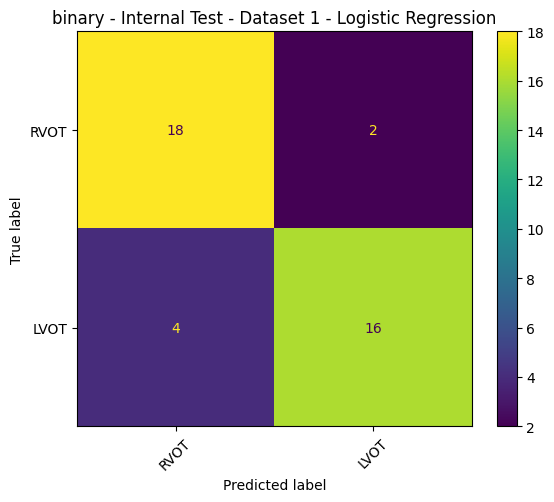


BINARY - BEST MODEL TEKNON-ONLY DEVELOPMENT HOLDOUT
Dataset used for training: Dataset 1
Model: Logistic Regression
Teknon-only development holdout: todas las clases están representadas.
Teknon-only holdout size: 28
Accuracy: 53.57%
Balanced Accuracy: 52.78%


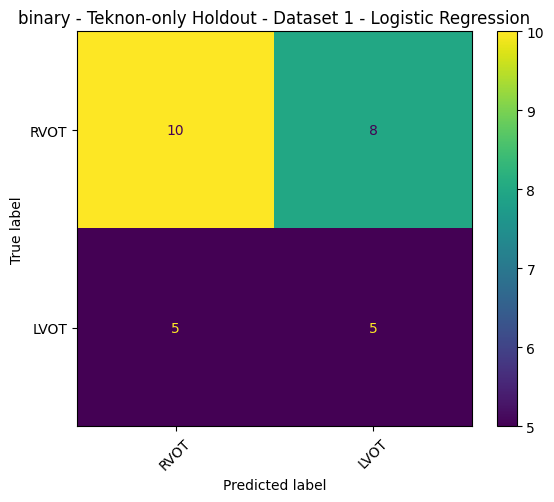

In [29]:
# ============================================================
# TASK 1: BINARY CLASSIFICATION — RVOT VS LVOT
# ============================================================

BINARY_MAPPING = {
    "RVOT Septum": 0,
    "RFW": 0,
    "RVOT Free Wall": 0,
    "RCC": 1,
    "LCC": 1,
    "COMMISSURE": 1,
    "COMMISURE": 1,
    "LVOT Summit": 1,
    "LVOT Subvalvular": 1
}

BINARY_TARGET_NAMES = [
    "RVOT",
    "LVOT"
]

experiment_binary = run_task(
    task_name="binary",
    target_mapping=BINARY_MAPPING,
    target_names=BINARY_TARGET_NAMES,
    n_per_class=100,
    include_mat=True,
    n_datasets=5,
    test_size=0.20
)

# Variables compatibles con los nombres utilizados
# en la versión anterior del notebook.
full_meta_pool = experiment_binary[
    "full_meta_pool"
]

full_qrs_pool = experiment_binary[
    "full_qrs_pool"
]

teknon_holdout_test_meta = experiment_binary[
    "teknon_holdout_test_meta"
]

teknon_holdout_test_qrs = experiment_binary[
    "teknon_holdout_test_qrs"
]

balanced_datasets_binary = experiment_binary[
    "balanced_datasets"
]

trained_models_binary_balanced = experiment_binary[
    "trained_models"
]

results_binary_balanced_5datasets = experiment_binary[
    "results"
]

best_result_binary_balanced = experiment_binary[
    "best_result"
]

cm_internal = experiment_binary[
    "cm_internal"
]

cm_teknon_external = experiment_binary[
    "cm_teknon_external"
]

teknon_external_acc = experiment_binary[
    "teknon_external_acc"
]

Official final Teknon test_set detected and kept untouched.

Class distribution before QRS filtering:
target
0    92
1    13
2    35
Name: count, dtype: int64

Teknon-only holdout split:
Clase 0: 74 paciente(s) en train + 18 paciente(s) en holdout.
Clase 1: 10 paciente(s) en train + 3 paciente(s) en holdout.
Clase 2: 28 paciente(s) en train + 7 paciente(s) en holdout.

Teknon-only development holdout reserved:
target
0    18
1     3
2     7
Name: count, dtype: int64

Training pool by source:
source
Teknon    112
Name: count, dtype: int64

Training pool by class:
target
0    74
1    10
2    28
Name: count, dtype: int64

----- Balanced dataset 1/5 -----

Internal balanced split:
Clase 0: 59 paciente(s) único(s) en train + 15 paciente(s) único(s) en test.
Clase 1: 8 paciente(s) único(s) en train + 2 paciente(s) único(s) en test.
Clase 2: 22 paciente(s) único(s) en train + 6 paciente(s) único(s) en test.
Leakage check passed: ningún paciente original aparece a la vez en train y test.


  File "c:\Users\senyo\Documentos\GitHub\Ciencia-de-dades-i-models-computacionals-en-biomedicina-\venv38\lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


QRS feature reduction: 1440 raw values -> 513 candidates -> 37 selected QRS features.
Ranking fitted on 74 unique Teknon training patients.
Top selected QRS variables: peak_to_peak_V4, maximum_V4, middle_absolute_area_V4, max_up_slope_V4, wave_V1_bin_13, minimum_V4, wave_V2_bin_11, max_down_slope_V5, wave_V2_bin_21, rms_V4, zero_crossing_rate_V5, peak_to_peak_V2
Final model matrix: 42 variables (37 QRS + 5 clinical).

----- Balanced dataset 2/5 -----

Internal balanced split:
Clase 0: 59 paciente(s) único(s) en train + 15 paciente(s) único(s) en test.
Clase 1: 8 paciente(s) único(s) en train + 2 paciente(s) único(s) en test.
Clase 2: 22 paciente(s) único(s) en train + 6 paciente(s) único(s) en test.
Leakage check passed: ningún paciente original aparece a la vez en train y test.
QRS feature reduction: 1440 raw values -> 513 candidates -> 38 selected QRS features.
Ranking fitted on 76 unique Teknon training patients.
Top selected QRS variables: peak_to_peak_V4, wave_V2_bin_11, rms_V2, a

,Dataset,Model,Accuracy (%),Balanced Accuracy (%),CV Accuracy (%),CV Balanced Accuracy (%)
3,Dataset 1,SVM RBF,66.67,66.67,89.56,89.33
4,Dataset 1,Gradient Boosting,58.33,58.33,93.74,93.78
1,Dataset 1,Extra Trees,50.00,50.00,94.46,94.37
0,Dataset 1,Random Forest,41.67,41.67,91.67,91.56
2,Dataset 1,Logistic Regression,36.11,36.11,91.67,91.78
6,Dataset 2,Extra Trees,55.56,55.56,93.03,93.19
5,Dataset 2,Random Forest,47.22,47.22,93.03,93.19
9,Dataset 2,Gradient Boosting,47.22,47.22,96.50,96.52
8,Dataset 2,SVM RBF,36.11,36.11,86.82,86.96
7,Dataset 2,Logistic Regression,25.00,25.00,88.18,88.30


Internal balanced test: todas las clases están representadas.

Best internal result: Dataset 5 - Random Forest | Accuracy 75.0% | Balanced Accuracy 75.0% |CV Accuracy 88.89% | CV Balanced Accuracy 89.11%


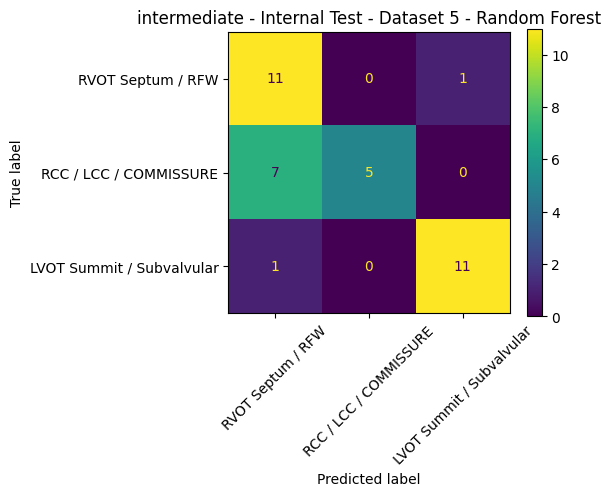


INTERMEDIATE - BEST MODEL TEKNON-ONLY DEVELOPMENT HOLDOUT
Dataset used for training: Dataset 5
Model: Random Forest
Teknon-only development holdout: todas las clases están representadas.
Teknon-only holdout size: 28
Accuracy: 75.00%
Balanced Accuracy: 59.79%


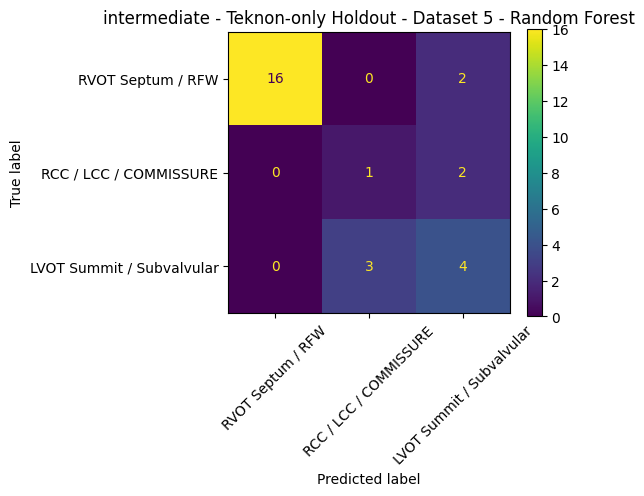

In [30]:
# ============================================================
# TASK 2: INTERMEDIATE MULTI-CLASS CLASSIFICATION
# ============================================================

INTERMEDIATE_MAPPING = {
    "RVOT Septum": 0,
    "RFW": 0,
    "RVOT Free Wall": 0,
    "RCC": 1,
    "LCC": 1,
    "COMMISSURE": 1,
    "COMMISURE": 1,
    "LVOT Summit": 2,
    "LVOT Subvalvular": 2
}

INTERMEDIATE_TARGET_NAMES = [
    "RVOT Septum / RFW",
    "RCC / LCC / COMMISSURE",
    "LVOT Summit / Subvalvular"
]

experiment_intermediate = run_task(
    task_name="intermediate",
    target_mapping=INTERMEDIATE_MAPPING,
    target_names=INTERMEDIATE_TARGET_NAMES,
    n_per_class=60,
    include_mat=False,
    n_datasets=5,
    test_size=0.20
)

# Variables compatibles con los nombres utilizados
# en la versión anterior del notebook.
full_meta_pool = experiment_intermediate[
    "full_meta_pool"
]

full_qrs_pool = experiment_intermediate[
    "full_qrs_pool"
]

teknon_holdout_test_meta = experiment_intermediate[
    "teknon_holdout_test_meta"
]

teknon_holdout_test_qrs = experiment_intermediate[
    "teknon_holdout_test_qrs"
]

balanced_datasets_intermediate = experiment_intermediate[
    "balanced_datasets"
]

trained_models_intermediate = experiment_intermediate[
    "trained_models"
]

results_intermediate = experiment_intermediate[
    "results"
]

best_result_intermediate = experiment_intermediate[
    "best_result"
]

cm_internal_intermediate = experiment_intermediate[
    "cm_internal"
]

cm_teknon_external_intermediate = experiment_intermediate[
    "cm_teknon_external"
]

teknon_external_acc_intermediate = experiment_intermediate[
    "teknon_external_acc"
]

teknon_external_bal_acc_intermediate = experiment_intermediate[
    "teknon_external_bal_acc"
]

Official final Teknon test_set detected and kept untouched.

Class distribution before QRS filtering:
target
0    50
1    42
2     9
3     3
4     1
5    11
6    24
Name: count, dtype: int64

Teknon-only holdout split:
Clase 0: 40 paciente(s) en train + 10 paciente(s) en holdout.
Clase 1: 34 paciente(s) en train + 8 paciente(s) en holdout.
Clase 2: 7 paciente(s) en train + 2 paciente(s) en holdout.
Clase 3: 2 paciente(s) en train + 1 paciente(s) en holdout.
[WARN] Clase 4: solo hay 1 paciente(s) Teknon único(s). Se mantienen exclusivamente en train y se excluyen del holdout Teknon-only para evitar leakage.
Clase 5: 9 paciente(s) en train + 2 paciente(s) en holdout.
Clase 6: 19 paciente(s) en train + 5 paciente(s) en holdout.

Teknon-only development holdout reserved:
target
0    10
1     8
2     2
3     1
5     2
6     5
Name: count, dtype: int64

Training pool by source:
source
Teknon    112
Name: count, dtype: int64

Training pool by class:
target
0    40
1    34
2     7
3     2
4   

,Dataset,Model,Accuracy (%),Balanced Accuracy (%),CV Accuracy (%),CV Balanced Accuracy (%)
1,Dataset 1,Extra Trees,55.56,55.56,82.71,82.86
0,Dataset 1,Random Forest,52.78,52.78,82.14,82.43
3,Dataset 1,SVM RBF,52.78,52.78,77.95,78.14
2,Dataset 1,Logistic Regression,44.44,44.44,80.93,81.14
4,Dataset 1,Gradient Boosting,30.56,30.56,78.56,78.86
7,Dataset 2,Logistic Regression,36.11,36.11,82.10,81.71
6,Dataset 2,Extra Trees,30.56,30.56,82.73,82.57
5,Dataset 2,Random Forest,27.78,27.78,82.69,82.71
8,Dataset 2,SVM RBF,27.78,27.78,80.30,80.29
9,Dataset 2,Gradient Boosting,16.67,16.67,83.89,83.86


[WARN] Internal balanced test: estas clases no se pueden evaluar de forma independiente porque no tienen pacientes disponibles en este test: COMMISSURE

Best internal result: Dataset 3 - Extra Trees | Accuracy 66.67% | Balanced Accuracy 66.67% |CV Accuracy 80.93% | CV Balanced Accuracy 81.0%


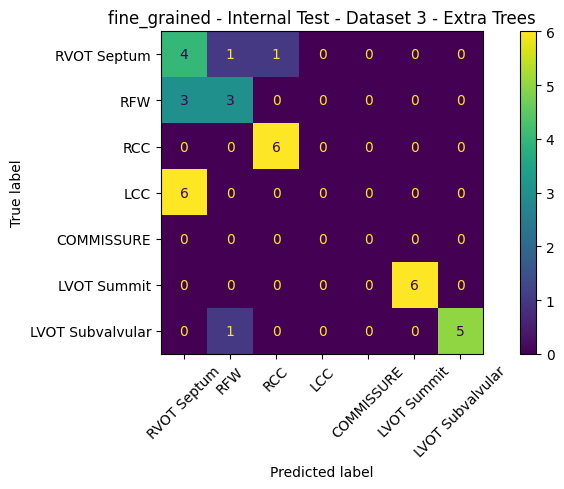


FINE_GRAINED - BEST MODEL TEKNON-ONLY DEVELOPMENT HOLDOUT
Dataset used for training: Dataset 3
Model: Extra Trees
[WARN] Teknon-only development holdout: estas clases no se pueden evaluar de forma independiente porque no tienen pacientes disponibles en este test: COMMISSURE
Teknon-only holdout size: 28
Accuracy: 42.86%
Balanced Accuracy: 25.42%


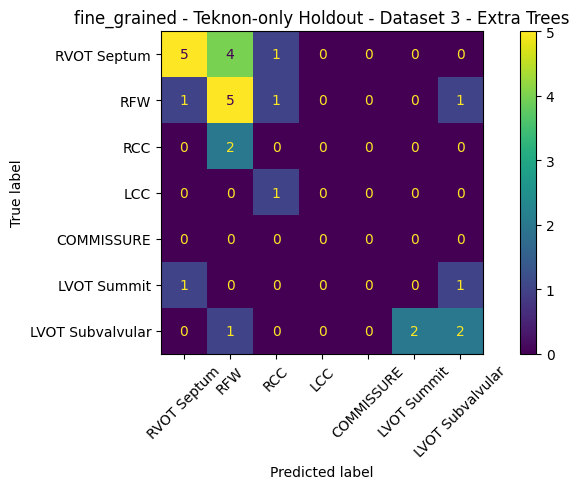

In [31]:
# ============================================================
# TASK 3: FINE-GRAINED MULTI-CLASS CLASSIFICATION
# ============================================================

FINE_GRAINED_MAPPING = {
    "RVOT Septum": 0,
    "RFW": 1,
    "RVOT Free Wall": 1,
    "RCC": 2,
    "LCC": 3,
    "COMMISSURE": 4,
    "COMMISURE": 4,
    "LVOT Summit": 5,
    "LVOT Subvalvular": 6
}

FINE_GRAINED_TARGET_NAMES = [
    "RVOT Septum",
    "RFW",
    "RCC",
    "LCC",
    "COMMISSURE",
    "LVOT Summit",
    "LVOT Subvalvular"
]

experiment_fine_grained = run_task(
    task_name="fine_grained",
    target_mapping=FINE_GRAINED_MAPPING,
    target_names=FINE_GRAINED_TARGET_NAMES,
    n_per_class=30,
    include_mat=False,
    n_datasets=5,
    test_size=0.20
)

# Variables compatibles con los nombres utilizados
# en la versión anterior del notebook.
full_meta_pool = experiment_fine_grained[
    "full_meta_pool"
]

full_qrs_pool = experiment_fine_grained[
    "full_qrs_pool"
]

teknon_holdout_test_meta = experiment_fine_grained[
    "teknon_holdout_test_meta"
]

teknon_holdout_test_qrs = experiment_fine_grained[
    "teknon_holdout_test_qrs"
]

balanced_datasets_fine_grained = experiment_fine_grained[
    "balanced_datasets"
]

trained_models_fine_grained = experiment_fine_grained[
    "trained_models"
]

results_fine_grained = experiment_fine_grained[
    "results"
]

best_result_fine_grained = experiment_fine_grained[
    "best_result"
]

cm_internal_fine_grained = experiment_fine_grained[
    "cm_internal"
]

cm_teknon_external_fine_grained = experiment_fine_grained[
    "cm_teknon_external"
]

teknon_external_acc_fine_grained = experiment_fine_grained[
    "teknon_external_acc"
]

teknon_external_bal_acc_fine_grained = experiment_fine_grained[
    "teknon_external_bal_acc"
]

### Without clinical features

Official final Teknon test_set detected and kept untouched.

Class distribution before QRS filtering:
target
0    92
1    48
Name: count, dtype: int64

Teknon-only holdout split:
Clase 0: 74 paciente(s) en train + 18 paciente(s) en holdout.
Clase 1: 38 paciente(s) en train + 10 paciente(s) en holdout.

Teknon-only development holdout reserved:
target
0    18
1    10
Name: count, dtype: int64

Training pool by source:
source
QRS_Database2    333
Teknon           112
QRS_CARTO2        43
Name: count, dtype: int64

Training pool by class:
target
0    347
1    141
Name: count, dtype: int64

----- Balanced dataset 1/5 -----

Internal balanced split:
Clase 0: 278 paciente(s) único(s) en train + 69 paciente(s) único(s) en test.
Clase 1: 113 paciente(s) único(s) en train + 28 paciente(s) único(s) en test.
Leakage check passed: ningún paciente original aparece a la vez en train y test.
QRS feature reduction: 1440 raw values -> 513 candidates -> 23 selected QRS features.
Ranking fitted on 47 uni

,Dataset,Model,Accuracy (%),Balanced Accuracy (%),CV Accuracy (%),CV Balanced Accuracy (%)
3,Dataset 1,SVM RBF,85.0,85.0,85.00,85.00
1,Dataset 1,Extra Trees,82.5,82.5,86.25,86.25
2,Dataset 1,Logistic Regression,80.0,80.0,82.50,82.50
0,Dataset 1,Random Forest,77.5,77.5,86.25,86.25
4,Dataset 1,Gradient Boosting,77.5,77.5,83.75,83.75
6,Dataset 2,Extra Trees,77.5,77.5,83.75,83.75
8,Dataset 2,SVM RBF,77.5,77.5,83.75,83.75
5,Dataset 2,Random Forest,75.0,75.0,81.25,81.25
7,Dataset 2,Logistic Regression,72.5,72.5,82.50,82.50
9,Dataset 2,Gradient Boosting,72.5,72.5,80.00,80.00


Internal balanced test: todas las clases están representadas.

Best internal result: Dataset 1 - SVM RBF | Accuracy 85.0% | Balanced Accuracy 85.0% |CV Accuracy 85.0% | CV Balanced Accuracy 85.0%


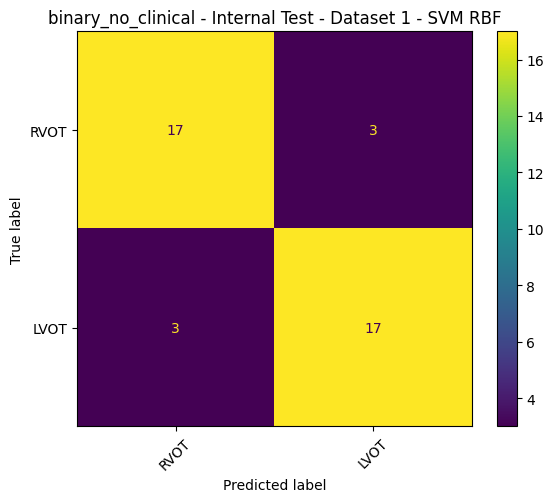


BINARY_NO_CLINICAL - BEST MODEL TEKNON-ONLY DEVELOPMENT HOLDOUT
Dataset used for training: Dataset 1
Model: SVM RBF
Teknon-only development holdout: todas las clases están representadas.
Teknon-only holdout size: 28
Accuracy: 60.71%
Balanced Accuracy: 60.56%


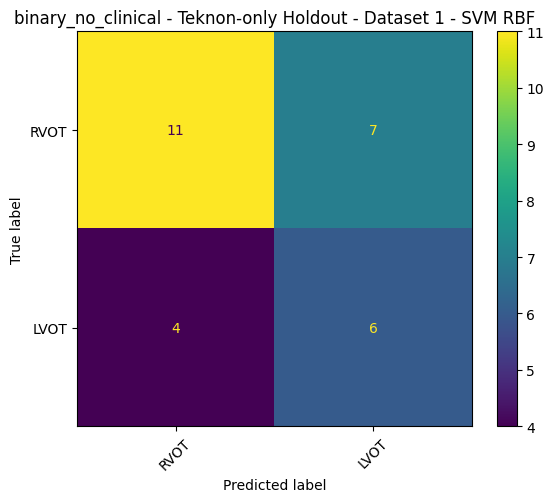

Official final Teknon test_set detected and kept untouched.

Class distribution before QRS filtering:
target
0    92
1    13
2    35
Name: count, dtype: int64

Teknon-only holdout split:
Clase 0: 74 paciente(s) en train + 18 paciente(s) en holdout.
Clase 1: 10 paciente(s) en train + 3 paciente(s) en holdout.
Clase 2: 28 paciente(s) en train + 7 paciente(s) en holdout.

Teknon-only development holdout reserved:
target
0    18
1     3
2     7
Name: count, dtype: int64

Training pool by source:
source
Teknon    112
Name: count, dtype: int64

Training pool by class:
target
0    74
1    10
2    28
Name: count, dtype: int64

----- Balanced dataset 1/5 -----

Internal balanced split:
Clase 0: 59 paciente(s) único(s) en train + 15 paciente(s) único(s) en test.
Clase 1: 8 paciente(s) único(s) en train + 2 paciente(s) único(s) en test.
Clase 2: 22 paciente(s) único(s) en train + 6 paciente(s) único(s) en test.
Leakage check passed: ningún paciente original aparece a la vez en train y test.
QRS f

,Dataset,Model,Accuracy (%),Balanced Accuracy (%),CV Accuracy (%),CV Balanced Accuracy (%)
3,Dataset 1,SVM RBF,58.33,58.33,88.15,87.93
0,Dataset 1,Random Forest,41.67,41.67,92.36,92.22
1,Dataset 1,Extra Trees,41.67,41.67,94.46,94.37
2,Dataset 1,Logistic Regression,33.33,33.33,89.58,89.56
4,Dataset 1,Gradient Boosting,27.78,27.78,90.99,90.96
9,Dataset 2,Gradient Boosting,50.00,50.00,94.43,94.59
5,Dataset 2,Random Forest,44.44,44.44,93.05,93.26
6,Dataset 2,Extra Trees,44.44,44.44,93.74,93.93
8,Dataset 2,SVM RBF,44.44,44.44,88.23,88.37
7,Dataset 2,Logistic Regression,22.22,22.22,89.56,89.78


Internal balanced test: todas las clases están representadas.

Best internal result: Dataset 5 - Random Forest | Accuracy 72.22% | Balanced Accuracy 72.22% |CV Accuracy 88.89% | CV Balanced Accuracy 89.11%


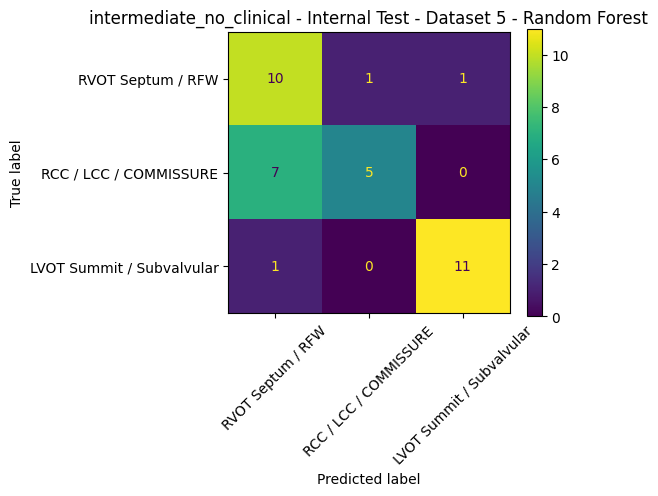


INTERMEDIATE_NO_CLINICAL - BEST MODEL TEKNON-ONLY DEVELOPMENT HOLDOUT
Dataset used for training: Dataset 5
Model: Random Forest
Teknon-only development holdout: todas las clases están representadas.
Teknon-only holdout size: 28
Accuracy: 75.00%
Balanced Accuracy: 59.79%


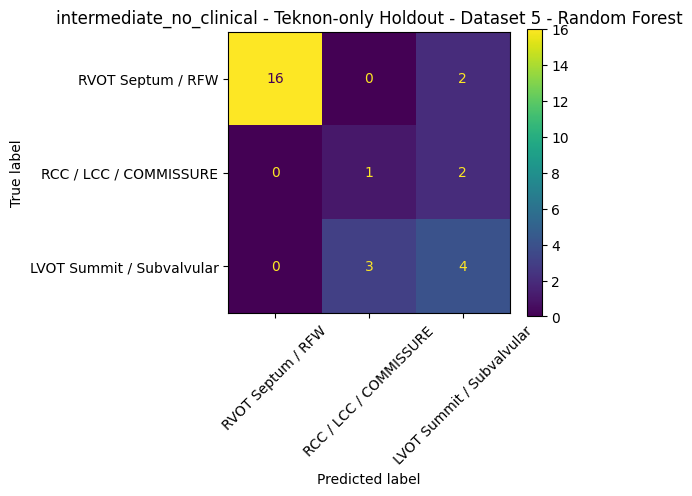

Official final Teknon test_set detected and kept untouched.

Class distribution before QRS filtering:
target
0    50
1    42
2     9
3     3
4     1
5    11
6    24
Name: count, dtype: int64

Teknon-only holdout split:
Clase 0: 40 paciente(s) en train + 10 paciente(s) en holdout.
Clase 1: 34 paciente(s) en train + 8 paciente(s) en holdout.
Clase 2: 7 paciente(s) en train + 2 paciente(s) en holdout.
Clase 3: 2 paciente(s) en train + 1 paciente(s) en holdout.
[WARN] Clase 4: solo hay 1 paciente(s) Teknon único(s). Se mantienen exclusivamente en train y se excluyen del holdout Teknon-only para evitar leakage.
Clase 5: 9 paciente(s) en train + 2 paciente(s) en holdout.
Clase 6: 19 paciente(s) en train + 5 paciente(s) en holdout.

Teknon-only development holdout reserved:
target
0    10
1     8
2     2
3     1
5     2
6     5
Name: count, dtype: int64

Training pool by source:
source
Teknon    112
Name: count, dtype: int64

Training pool by class:
target
0    40
1    34
2     7
3     2
4   

,Dataset,Model,Accuracy (%),Balanced Accuracy (%),CV Accuracy (%),CV Balanced Accuracy (%)
1,Dataset 1,Extra Trees,58.33,58.33,85.10,85.29
0,Dataset 1,Random Forest,55.56,55.56,82.73,82.86
3,Dataset 1,SVM RBF,50.00,50.00,76.81,76.86
2,Dataset 1,Logistic Regression,47.22,47.22,79.71,80.14
4,Dataset 1,Gradient Boosting,25.00,25.00,80.37,80.71
8,Dataset 2,SVM RBF,47.22,47.22,80.93,80.86
7,Dataset 2,Logistic Regression,38.89,38.89,80.34,80.14
6,Dataset 2,Extra Trees,36.11,36.11,82.71,82.57
5,Dataset 2,Random Forest,25.00,25.00,82.67,82.86
9,Dataset 2,Gradient Boosting,22.22,22.22,85.10,85.14


[WARN] Internal balanced test: estas clases no se pueden evaluar de forma independiente porque no tienen pacientes disponibles en este test: COMMISSURE

Best internal result: Dataset 3 - Extra Trees | Accuracy 61.11% | Balanced Accuracy 61.11% |CV Accuracy 80.94% | CV Balanced Accuracy 81.14%


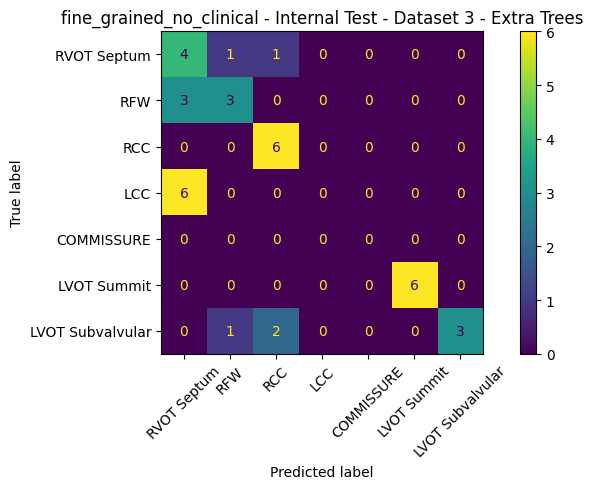


FINE_GRAINED_NO_CLINICAL - BEST MODEL TEKNON-ONLY DEVELOPMENT HOLDOUT
Dataset used for training: Dataset 3
Model: Extra Trees
[WARN] Teknon-only development holdout: estas clases no se pueden evaluar de forma independiente porque no tienen pacientes disponibles en este test: COMMISSURE
Teknon-only holdout size: 28
Accuracy: 39.29%
Balanced Accuracy: 23.33%


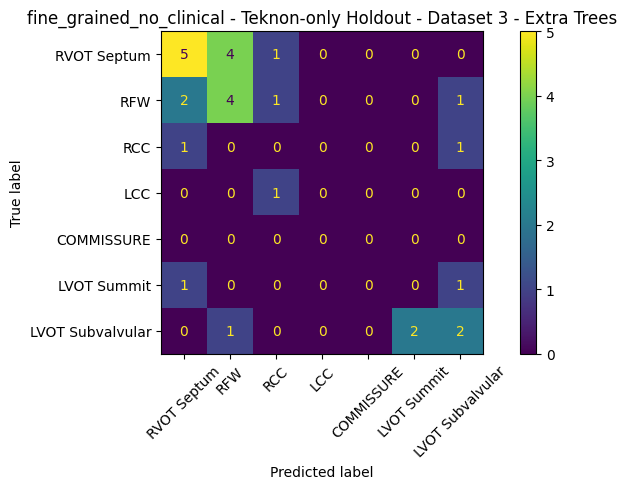

In [32]:
# ============================================================
# TASKS 1, 2, 3 - WITHOUT CLINICAL FEATURES
# ============================================================

# Task 1 - no clinical
experiment_binary_no_clin = run_task(
    task_name="binary_no_clinical",
    target_mapping=BINARY_MAPPING,
    target_names=BINARY_TARGET_NAMES,
    n_per_class=100,
    include_mat=True,
    n_datasets=5,
    test_size=0.20,
    use_clinical=False
)

# Task 2 - no clinical
experiment_intermediate_no_clin = run_task(
    task_name="intermediate_no_clinical",
    target_mapping=INTERMEDIATE_MAPPING,
    target_names=INTERMEDIATE_TARGET_NAMES,
    n_per_class=60,
    include_mat=False,
    n_datasets=5,
    test_size=0.20,
    use_clinical=False
)

# Task 3 - no clinical
experiment_fine_grained_no_clin = run_task(
    task_name="fine_grained_no_clinical",
    target_mapping=FINE_GRAINED_MAPPING,
    target_names=FINE_GRAINED_TARGET_NAMES,
    n_per_class=30,
    include_mat=False,
    n_datasets=5,
    test_size=0.20,
    use_clinical=False
)

In [33]:
# Best model per task segons internal test
print("=== TASK 1 ===")
print(experiment_binary['best_result'])

print("\n=== TASK 2 ===")
print(experiment_intermediate['best_result'])

=== TASK 1 ===
Dataset                               Dataset 1
Model                       Logistic Regression
CV Accuracy                               0.825
CV Balanced Accuracy                      0.825
Accuracy                                   0.85
Balanced Accuracy                          0.85
Accuracy (%)                               85.0
Balanced Accuracy (%)                      85.0
CV Accuracy (%)                            82.5
CV Balanced Accuracy (%)                   82.5
Name: 2, dtype: object

=== TASK 2 ===
Dataset                         Dataset 5
Model                       Random Forest
CV Accuracy                      0.888916
CV Balanced Accuracy             0.891111
Accuracy                             0.75
Balanced Accuracy                    0.75
Accuracy (%)                         75.0
Balanced Accuracy (%)                75.0
CV Accuracy (%)                     88.89
CV Balanced Accuracy (%)            89.11
Name: 20, dtype: object


### CNN

In [34]:
def train_cnn_epoch(model, train_loader, criterion, optimizer, device):
    """Train CNN for one epoch."""
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(train_loader)


def evaluate_cnn_val(model, val_loader, criterion, device):
    """Evaluate CNN on validation set."""
    model.eval()
    val_loss = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            output = model(X_batch)
            loss = criterion(output, y_batch)
            val_loss += loss.item()
            preds = output.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.cpu().numpy())
    return val_loss / len(val_loader), np.array(all_preds), np.array(all_labels)


def train_cnn_with_cv(X_tensor, y_array, n_leads=12, n_classes=2, cv_splits=5, 
                       n_epochs=100, patience=15, batch_size=32, device=None):
    """
    Train CNN with stratified K-fold cross-validation.
    Returns: cv_scores dict, final_model trained on full data, fold_models list
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    skf = SKFold(n_splits=cv_splits, shuffle=True, random_state=RANDOM_STATE)
    cv_train_losses = []
    cv_val_losses = []
    cv_accuracies = []
    cv_bal_accuracies = []
    fold_models = []
    
    fold_idx = 0
    for train_idx, val_idx in skf.split(X_tensor.numpy(), y_array):
        fold_idx += 1
        print(f"  CV Fold {fold_idx}/{cv_splits}")
        
        # Create fold datasets
        train_subset = Subset(TensorDataset(X_tensor, torch.tensor(y_array, dtype=torch.long)), train_idx)
        val_subset = Subset(TensorDataset(X_tensor, torch.tensor(y_array, dtype=torch.long)), val_idx)
        
        train_loader_cv = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
        val_loader_cv = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
        
        # Initialize model for this fold
        torch.manual_seed(RANDOM_STATE + fold_idx)
        model_fold = QRS_CNN(n_leads=n_leads, n_classes=n_classes).to(device)
        
        # Class weights for this fold
        fold_class_counts = np.bincount(y_array[train_idx])
        fold_class_weights = torch.tensor(1.0 / fold_class_counts, dtype=torch.float32).to(device)
        
        criterion = nn.CrossEntropyLoss(weight=fold_class_weights)
        optimizer = optim.Adam(model_fold.parameters(), lr=1e-3, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)
        
        best_val_loss = float("inf")
        best_weights = None
        epochs_no_improve = 0
        
        for epoch in range(n_epochs):
            train_loss = train_cnn_epoch(model_fold, train_loader_cv, criterion, optimizer, device)
            val_loss, val_preds, val_labels = evaluate_cnn_val(model_fold, val_loader_cv, criterion, device)
            scheduler.step()
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_weights = model_fold.state_dict().copy()
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
            
            if epochs_no_improve >= patience:
                break
        
        model_fold.load_state_dict(best_weights)
        fold_models.append(model_fold)
        
        # Compute fold metrics
        from sklearn.metrics import accuracy_score, balanced_accuracy_score
        fold_acc = accuracy_score(val_labels, val_preds)
        fold_bal_acc = balanced_accuracy_score(val_labels, val_preds)
        
        cv_train_losses.append(train_loss)
        cv_val_losses.append(best_val_loss)
        cv_accuracies.append(fold_acc)
        cv_bal_accuracies.append(fold_bal_acc)
        
        print(f"    Fold {fold_idx} | Val Loss: {best_val_loss:.4f} | Acc: {fold_acc:.4f} | Bal Acc: {fold_bal_acc:.4f}")
    
    # Train final model on full data
    torch.manual_seed(RANDOM_STATE)
    model_final = QRS_CNN(n_leads=n_leads, n_classes=n_classes).to(device)
    full_class_counts = np.bincount(y_array)
    full_class_weights = torch.tensor(1.0 / full_class_counts, dtype=torch.float32).to(device)
    criterion = nn.CrossEntropyLoss(weight=full_class_weights)
    optimizer = optim.Adam(model_final.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)
    
    full_train_loader = DataLoader(TensorDataset(X_tensor, torch.tensor(y_array, dtype=torch.long)), 
                                   batch_size=batch_size, shuffle=True)
    best_val_loss = float("inf")
    
    for epoch in range(n_epochs):
        train_loss = train_cnn_epoch(model_final, full_train_loader, criterion, optimizer, device)
        scheduler.step()
    
    return {
        "cv_accuracy": np.mean(cv_accuracies),
        "cv_accuracy_std": np.std(cv_accuracies),
        "cv_balanced_accuracy": np.mean(cv_bal_accuracies),
        "cv_balanced_accuracy_std": np.std(cv_bal_accuracies),
        "cv_val_loss": np.mean(cv_val_losses),
    }, model_final

In [35]:
# Retrieve train and holdout indices from the binary experiment
holdout_idx = experiment_binary['teknon_holdout_test_meta'].index.tolist()
train_idx = experiment_binary['full_meta_pool'].index.tolist()

print("Train pool size:", len(train_idx))
print("Holdout size:", len(holdout_idx))

# Verify no patient appears in both sets
overlap = set(holdout_idx).intersection(set(train_idx))
print("Overlap:", len(overlap))

Train pool size: 488
Holdout size: 28
Overlap: 0


In [36]:
# Check data sources in the training pool
print(experiment_binary['full_meta_pool']['source'].value_counts())

source
QRS_Database2    333
Teknon           112
QRS_CARTO2        43
Name: count, dtype: int64


In [37]:
print(experiment_binary['full_qrs_pool'].shape)
print(experiment_binary['full_meta_pool']['target'].value_counts())

(488, 1440)
target
0    347
1    141
Name: count, dtype: int64


Train shape: (488, 12, 120) | Class distribution: [347 141]
Holdout shape: (28, 12, 120) | Class distribution: [18 10]
Device: cpu

Training CNN with 5-fold stratified cross-validation...
  CV Fold 1/5
    Fold 1 | Val Loss: 0.6439 | Acc: 0.7551 | Bal Acc: 0.6036
  CV Fold 2/5
    Fold 2 | Val Loss: 0.6171 | Acc: 0.7143 | Bal Acc: 0.5750
  CV Fold 3/5
    Fold 3 | Val Loss: 0.6624 | Acc: 0.6837 | Bal Acc: 0.5255
  CV Fold 4/5
    Fold 4 | Val Loss: 0.6806 | Acc: 0.7216 | Bal Acc: 0.5603
  CV Fold 5/5
    Fold 5 | Val Loss: 0.6609 | Acc: 0.7216 | Bal Acc: 0.5815

Cross-validation results (Full dataset):
  CV Accuracy: 0.7193 ± 0.0227
  CV Balanced Accuracy: 0.5692 ± 0.0259
  CV Val Loss: 0.6530

CNN - BINARY TASK - ALL DATASETS
Accuracy:                  75.00%
Balanced Accuracy:         76.11%
Macro-average Sensitivity: 76.11%

Classification Report:
              precision    recall  f1-score   support

        RVOT       0.87      0.72      0.79        18
        LVOT       0.62     

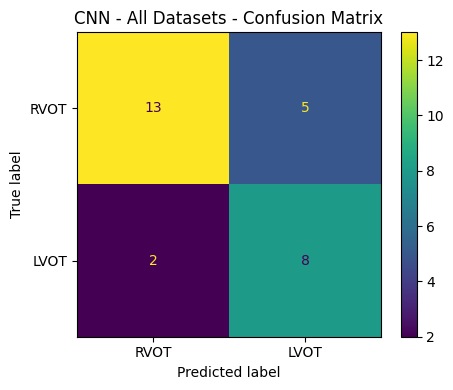

In [42]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay, recall_score, classification_report
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold as SKFold

# ============================================================
# 1. DATA PREPARATION
# ============================================================

# Retrieve train and holdout sets from the binary experiment
X_raw_train = experiment_binary['full_qrs_pool'].to_numpy(dtype=float)
y_train_raw  = experiment_binary['full_meta_pool']['target'].astype(int).to_numpy()

X_raw_holdout = experiment_binary['teknon_holdout_test_qrs'].to_numpy(dtype=float)
y_holdout_raw  = experiment_binary['teknon_holdout_test_meta']['target'].astype(int).to_numpy()

# Reshape to (n, channels, length) as required by PyTorch Conv1d
# Each ECG lead is treated as an independent channel over 120 time steps
X_train   = X_raw_train.reshape(-1, 120, 12).transpose(0, 2, 1)    # (488, 12, 120)
X_holdout = X_raw_holdout.reshape(-1, 120, 12).transpose(0, 2, 1)  # (28, 12, 120)

print("Train shape:", X_train.shape, "| Class distribution:", np.bincount(y_train_raw))
print("Holdout shape:", X_holdout.shape, "| Class distribution:", np.bincount(y_holdout_raw))

X_train_t   = torch.tensor(X_train,   dtype=torch.float32)
X_holdout_t = torch.tensor(X_holdout, dtype=torch.float32)
y_train_t   = torch.tensor(y_train_raw, dtype=torch.long)
y_holdout_t = torch.tensor(y_holdout_raw, dtype=torch.long)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=32, shuffle=True
)

holdout_loader = DataLoader(
    TensorDataset(X_holdout_t, y_holdout_t),
    batch_size=32, shuffle=False
)


# ============================================================
# 2. CNN ARCHITECTURE
# ============================================================

class QRS_CNN(nn.Module):
    """
    1D CNN for binary RVOT/LVOT classification from QRS morphology.
    Each ECG lead is treated as an independent input channel.
    Two convolutional blocks extract local temporal features,
    followed by global average pooling and a fully connected classifier.
    """
    def __init__(self, n_leads=12, n_classes=2):
        super(QRS_CNN, self).__init__()

        # First convolutional block
        self.conv1 = nn.Sequential(
            nn.Conv1d(n_leads, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
        )

        # Second convolutional block
        self.conv2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
        )

        # Global average pooling reduces spatial dimension to 1
        self.gap = nn.AdaptiveAvgPool1d(1)

        # Fully connected classifier with dropout regularization
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x


# ============================================================
# 3. TRAINING WITH K-FOLD CROSS-VALIDATION (CNN - ALL DATASETS)
# ============================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

print("\nTraining CNN with 5-fold stratified cross-validation...")
cv_scores_full, model_cnn_full = train_cnn_with_cv(
    X_train_t, y_train_raw,
    n_leads=12, n_classes=2,
    cv_splits=5, n_epochs=100, patience=15,
    batch_size=32, device=device
)

print(f"\nCross-validation results (Full dataset):")
print(f"  CV Accuracy: {cv_scores_full['cv_accuracy']:.4f} ± {cv_scores_full['cv_accuracy_std']:.4f}")
print(f"  CV Balanced Accuracy: {cv_scores_full['cv_balanced_accuracy']:.4f} ± {cv_scores_full['cv_balanced_accuracy_std']:.4f}")
print(f"  CV Val Loss: {cv_scores_full['cv_val_loss']:.4f}")


# ============================================================
# 4. EVALUATION
# ============================================================



model_cnn_full.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in holdout_loader:
        X_batch = X_batch.to(device)
        output  = model_cnn_full(X_batch)
        preds   = output.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

acc        = accuracy_score(all_labels, all_preds)
bal_acc    = balanced_accuracy_score(all_labels, all_preds)
macro_sens = recall_score(all_labels, all_preds, average='macro', zero_division=0)

print("\n==============================")
print("CNN - BINARY TASK - ALL DATASETS")
print("==============================")
print(f"Accuracy:                  {acc*100:.2f}%")
print(f"Balanced Accuracy:         {bal_acc*100:.2f}%")
print(f"Macro-average Sensitivity: {macro_sens*100:.2f}%")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["RVOT", "LVOT"], zero_division=0))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["RVOT", "LVOT"]
).plot(ax=ax, values_format="d")
plt.title("CNN - All Datasets - Confusion Matrix")
plt.tight_layout()
plt.show()

In [43]:
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_preds,
    target_names=["RVOT", "LVOT"],
    zero_division=0
))

              precision    recall  f1-score   support

        RVOT       0.87      0.72      0.79        18
        LVOT       0.62      0.80      0.70        10

    accuracy                           0.75        28
   macro avg       0.74      0.76      0.74        28
weighted avg       0.78      0.75      0.75        28



In [44]:
# COMPARISON WITH THE PAPER
from sklearn.metrics import recall_score

macro_sensitivity = recall_score(
    all_labels,
    all_preds,
    average='macro',
    zero_division=0
)

print(f"Macro-average sensitivity: {macro_sensitivity*100:.2f}%")

Macro-average sensitivity: 76.11%


In [45]:
# Check Teknon-only samples in the training pool
teknon_mask = experiment_binary['full_meta_pool']['source'] == 'Teknon'
print("Teknon train samples:", teknon_mask.sum())
print("Class distribution:")
print(experiment_binary['full_meta_pool'][teknon_mask]['target'].value_counts())

Teknon train samples: 112
Class distribution:
target
0    74
1    38
Name: count, dtype: int64


Train shape: (112, 12, 120) | Class distribution: [74 38]
Holdout shape: (28, 12, 120) | Class distribution: [18 10]

Training CNN (Teknon) with 5-fold stratified cross-validation...
  CV Fold 1/5
    Fold 1 | Val Loss: 0.4363 | Acc: 0.7826 | Bal Acc: 0.8042
  CV Fold 2/5
    Fold 2 | Val Loss: 0.4154 | Acc: 0.7391 | Bal Acc: 0.7708
  CV Fold 3/5
    Fold 3 | Val Loss: 0.6133 | Acc: 0.7273 | Bal Acc: 0.7238
  CV Fold 4/5
    Fold 4 | Val Loss: 0.4716 | Acc: 0.7727 | Bal Acc: 0.7952
  CV Fold 5/5
    Fold 5 | Val Loss: 0.4347 | Acc: 0.6818 | Bal Acc: 0.6429

Cross-validation results (Teknon):
  CV Accuracy: 0.7407 ± 0.0359
  CV Balanced Accuracy: 0.7474 ± 0.0592
  CV Val Loss: 0.4743

CNN - BINARY TASK - TEKNON ONLY
Accuracy:                  67.86%
Balanced Accuracy:         66.11%
Macro-average Sensitivity: 66.11%

Classification Report:
              precision    recall  f1-score   support

        RVOT       0.76      0.72      0.74        18
        LVOT       0.55      0.60      0

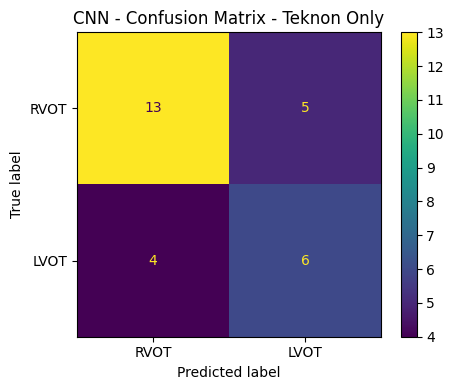

In [46]:
# ============================================================
# CNN - BINARY TASK (TEKNON ONLY)
# ============================================================

# Select only Teknon samples from the training pool
teknon_mask = experiment_binary['full_meta_pool']['source'] == 'Teknon'
teknon_meta = experiment_binary['full_meta_pool'][teknon_mask]
teknon_qrs  = experiment_binary['full_qrs_pool'].loc[teknon_meta.index]

X_raw_train = teknon_qrs.to_numpy(dtype=float)
y_train_raw  = teknon_meta['target'].astype(int).to_numpy()

X_raw_holdout = experiment_binary['teknon_holdout_test_qrs'].to_numpy(dtype=float)
y_holdout_raw  = experiment_binary['teknon_holdout_test_meta']['target'].astype(int).to_numpy()

# Reshape to (n, channels, length) as required by PyTorch Conv1d
X_train   = X_raw_train.reshape(-1, 120, 12).transpose(0, 2, 1)
X_holdout = X_raw_holdout.reshape(-1, 120, 12).transpose(0, 2, 1)

print("Train shape:", X_train.shape, "| Class distribution:", np.bincount(y_train_raw))
print("Holdout shape:", X_holdout.shape, "| Class distribution:", np.bincount(y_holdout_raw))

# Convert to PyTorch tensors
X_train_t   = torch.tensor(X_train,   dtype=torch.float32)
X_holdout_t = torch.tensor(X_holdout, dtype=torch.float32)
y_train_t   = torch.tensor(y_train_raw, dtype=torch.long)
y_holdout_t = torch.tensor(y_holdout_raw, dtype=torch.long)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=16,
    shuffle=True
)

holdout_loader = DataLoader(
    TensorDataset(X_holdout_t, y_holdout_t),
    batch_size=16,
    shuffle=False
)

print("\nTraining CNN (Teknon) with 5-fold stratified cross-validation...")
cv_scores_teknon, model_teknon = train_cnn_with_cv(
    X_train_t, y_train_raw,
    n_leads=12, n_classes=2,
    cv_splits=5, n_epochs=100, patience=15,
    batch_size=32, device=device
)

print(f"\nCross-validation results (Teknon):") 
print(f"  CV Accuracy: {cv_scores_teknon['cv_accuracy']:.4f} ± {cv_scores_teknon['cv_accuracy_std']:.4f}")
print(f"  CV Balanced Accuracy: {cv_scores_teknon['cv_balanced_accuracy']:.4f} ± {cv_scores_teknon['cv_balanced_accuracy_std']:.4f}")
print(f"  CV Val Loss: {cv_scores_teknon['cv_val_loss']:.4f}")

# Evaluation on holdout set

model_teknon.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in holdout_loader:
        X_batch = X_batch.to(device)
        output  = model_teknon(X_batch)
        preds   = output.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

acc          = accuracy_score(all_labels, all_preds)
bal_acc      = balanced_accuracy_score(all_labels, all_preds)
macro_sens   = recall_score(all_labels, all_preds, average='macro', zero_division=0)

print("\n==============================")
print("CNN - BINARY TASK - TEKNON ONLY")
print("==============================")
print(f"Accuracy:                  {acc*100:.2f}%")
print(f"Balanced Accuracy:         {bal_acc*100:.2f}%")
print(f"Macro-average Sensitivity: {macro_sens*100:.2f}%")

print("\nClassification Report:")
print(classification_report(
    all_labels,
    all_preds,
    target_names=["RVOT", "LVOT"],
    zero_division=0
))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["RVOT", "LVOT"]
).plot(ax=ax, values_format="d")
plt.title("CNN - Confusion Matrix - Teknon Only")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# DATA AUGMENTATION - FULL TRAINING POOL (Teknon + .mat)
# ============================================================

def augment_qrs(X, y, n_augmentations=3, noise_std=0.008, scale_range=0.10, random_state=RANDOM_STATE):
    """
    Applies clinically valid augmentations to QRS signals:
    - Gaussian noise: simulates electrode measurement noise
    - Amplitude scaling: simulates inter-patient electrode placement variability
    Both perturbations preserve QRS morphology and diagnostic features.
    
    X: (n, 12, 120)
    y: (n,)
    """
    rng = np.random.default_rng(random_state)
    
    X_aug = [X]
    y_aug = [y]
    
    for _ in range(n_augmentations):
        # Gaussian noise augmentation
        noise = rng.normal(0, noise_std, X.shape)
        X_aug.append(X + noise)
        y_aug.append(y)
        
        # Amplitude scaling augmentation
        scale = rng.uniform(1 - scale_range, 1 + scale_range, (X.shape[0], 1, 1))
        X_aug.append(X * scale)
        y_aug.append(y)
    
    X_augmented = np.concatenate(X_aug, axis=0)
    y_augmented = np.concatenate(y_aug, axis=0)
    
    # Shuffle to avoid order bias
    idx = rng.permutation(len(X_augmented))
    
    return X_augmented[idx], y_augmented[idx]


# Load full training pool (Teknon + .mat datasets)
X_raw_train_full = experiment_binary['full_qrs_pool'].to_numpy(dtype=float)
y_train_raw_full = experiment_binary['full_meta_pool']['target'].astype(int).to_numpy()
X_train_full     = X_raw_train_full.reshape(-1, 120, 12).transpose(0, 2, 1)  # (488, 12, 120)

# Load holdout set
X_raw_holdout_aug = experiment_binary['teknon_holdout_test_qrs'].to_numpy(dtype=float)
y_holdout_aug     = experiment_binary['teknon_holdout_test_meta']['target'].astype(int).to_numpy()
X_holdout_aug     = X_raw_holdout_aug.reshape(-1, 120, 12).transpose(0, 2, 1)

# Apply augmentation to training data only
X_train_augmented, y_train_augmented = augment_qrs(
    X_train_full,
    y_train_raw_full,
    n_augmentations=3,
    noise_std=0.008,
    scale_range=0.10
)

print("Original train size:", X_train_full.shape[0])
print("Augmented train size:", X_train_augmented.shape[0])
print("Class distribution after augmentation:", np.bincount(y_train_augmented))

# Convert to PyTorch tensors
X_train_aug_t   = torch.tensor(X_train_augmented, dtype=torch.float32)
y_train_aug_t   = torch.tensor(y_train_augmented, dtype=torch.long)
X_holdout_aug_t = torch.tensor(X_holdout_aug,     dtype=torch.float32)
y_holdout_aug_t = torch.tensor(y_holdout_aug,     dtype=torch.long)

train_loader_aug   = DataLoader(
    TensorDataset(X_train_aug_t, y_train_aug_t),
    batch_size=32,
    shuffle=True
)

holdout_loader_aug = DataLoader(
    TensorDataset(X_holdout_aug_t, y_holdout_aug_t),
    batch_size=32,
    shuffle=False
)

# ============================================================
# TRAINING WITH AUGMENTED DATA
# ============================================================
print("\nTraining CNN (Augmented) with 5-fold stratified cross-validation...")
cv_scores_aug, model_aug = train_cnn_with_cv(
    X_train_aug_t, y_train_augmented,
    n_leads=12, n_classes=2,
    cv_splits=5, n_epochs=100, patience=15,
    batch_size=32, device=device
)

class_counts_aug = np.bincount(y_train_augmented)
class_weights_aug = torch.tensor(1.0 / class_counts_aug, dtype=torch.float32).to(device)
criterion_aug = nn.CrossEntropyLoss(weight=class_weights_aug)
optimizer_aug = optim.Adam(model_aug.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_aug = optim.lr_scheduler.StepLR(optimizer_aug, step_size=20, gamma=0.5)

print(f"\nCross-validation results (Augmented):")
print(f"  CV Accuracy: {cv_scores_aug['cv_accuracy']:.4f} ± {cv_scores_aug['cv_accuracy_std']:.4f}")
print(f"  CV Balanced Accuracy: {cv_scores_aug['cv_balanced_accuracy']:.4f} ± {cv_scores_aug['cv_balanced_accuracy_std']:.4f}")
print(f"  CV Val Loss: {cv_scores_aug['cv_val_loss']:.4f}")

# Evaluation on holdout set
model_aug.eval()
preds_aug = []
labels_aug = []

with torch.no_grad():
    for X_batch, y_batch in holdout_loader_aug:
        X_batch = X_batch.to(device)
        output = model_aug(X_batch)
        preds = output.argmax(dim=1).cpu().numpy()
        preds_aug.extend(preds)
        labels_aug.extend(y_batch.numpy())

        preds_aug = np.array(preds_aug)
        labels_aug = np.array(labels_aug)
        y_batch = y_batch.to(device)

        optimizer_aug.zero_grad()
        output = model_aug(X_batch)
        loss   = criterion_aug(output, y_batch)
        loss.backward()
        optimizer_aug.step()
        epoch_loss += loss.item()

    train_losses_aug.append(epoch_loss / len(train_loader_aug))

    model_aug.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in holdout_loader_aug:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            output  = model_aug(X_batch)
            loss    = criterion_aug(output, y_batch)
            val_loss += loss.item()

    val_losses_aug.append(val_loss / len(holdout_loader_aug))
    scheduler_aug.step()

    if val_losses_aug[-1] < best_val_loss_aug:
        best_val_loss_aug     = val_losses_aug[-1]
        best_weights_aug      = model_aug.state_dict().copy()
        epochs_no_improve_aug = 0
    else:
        epochs_no_improve_aug += 1

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{N_EPOCHS_AUG} | Train Loss: {train_losses_aug[-1]:.4f} | Val Loss: {val_losses_aug[-1]:.4f}")

    if epochs_no_improve_aug >= PATIENCE_AUG:
        print(f"\nEarly stopping at epoch {epoch+1}.")

model_aug.load_state_dict(best_weights_aug)
print(f"Best val loss: {best_val_loss_aug:.4f}")

# ============================================================
# EVALUATION
# ============================================================

plt.figure(figsize=(8, 4))
plt.plot(train_losses_aug, label='Train Loss')
plt.plot(val_losses_aug,   label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN + Augmentation - Training Curve')
plt.legend()
plt.tight_layout()
plt.show()

model_aug.eval()
preds_aug  = []
labels_aug = []

with torch.no_grad():
    for X_batch, y_batch in holdout_loader_aug:
        X_batch = X_batch.to(device)
        output  = model_aug(X_batch)
        preds   = output.argmax(dim=1).cpu().numpy()
        preds_aug.extend(preds)
        labels_aug.extend(y_batch.numpy())

preds_aug  = np.array(preds_aug)
labels_aug = np.array(labels_aug)

acc_aug        = accuracy_score(labels_aug, preds_aug)
bal_acc_aug    = balanced_accuracy_score(labels_aug, preds_aug)
macro_sens_aug = recall_score(labels_aug, preds_aug, average='macro', zero_division=0)

print("\n==============================")
print("CNN + AUGMENTATION - BINARY TASK RESULTS")
print("==============================")
print(f"Accuracy:                  {acc_aug*100:.2f}%")
print(f"Balanced Accuracy:         {bal_acc_aug*100:.2f}%")
print(f"Macro-average Sensitivity: {macro_sens_aug*100:.2f}%")

print("\nClassification Report:")
print(classification_report(
    labels_aug,
    preds_aug,
    target_names=["RVOT", "LVOT"],
    zero_division=0
))

cm_aug = confusion_matrix(labels_aug, preds_aug)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix=cm_aug,
    display_labels=["RVOT", "LVOT"]
).plot(ax=ax, values_format="d")
plt.title("CNN + Augmentation - Confusion Matrix")
plt.tight_layout()
plt.show()

Original train size: 488
Augmented train size: 3416
Class distribution after augmentation: [2429  987]

Training CNN (Augmented) with 5-fold stratified cross-validation...
  CV Fold 1/5
    Fold 1 | Val Loss: 0.4545 | Acc: 0.8041 | Bal Acc: 0.7634
  CV Fold 2/5
    Fold 2 | Val Loss: 0.4957 | Acc: 0.7072 | Bal Acc: 0.7340
  CV Fold 3/5


In [ ]:
# ============================================================
# CNN + AUGMENTATION - TEKNON ONLY
# ============================================================

# Load Teknon-only training samples
teknon_mask_full = experiment_binary['full_meta_pool']['source'] == 'Teknon'
teknon_meta_full = experiment_binary['full_meta_pool'][teknon_mask_full]
teknon_qrs_full  = experiment_binary['full_qrs_pool'].loc[teknon_meta_full.index]

X_raw_teknon = teknon_qrs_full.to_numpy(dtype=float)
y_raw_teknon = teknon_meta_full['target'].astype(int).to_numpy()
X_teknon     = X_raw_teknon.reshape(-1, 120, 12).transpose(0, 2, 1)  # (112, 12, 120)

# Apply augmentation to Teknon training data only
X_teknon_aug, y_teknon_aug = augment_qrs(
    X_teknon,
    y_raw_teknon,
    n_augmentations=3,
    noise_std=0.008,
    scale_range=0.10
)

print("Original train size:", X_teknon.shape[0])
print("Augmented train size:", X_teknon_aug.shape[0])
print("Class distribution after augmentation:", np.bincount(y_teknon_aug))

# Convert to PyTorch tensors
X_teknon_aug_t   = torch.tensor(X_teknon_aug, dtype=torch.float32)
y_teknon_aug_t   = torch.tensor(y_teknon_aug, dtype=torch.long)
X_holdout_taug_t = torch.tensor(X_holdout_aug, dtype=torch.float32)
y_holdout_taug_t = torch.tensor(y_holdout_aug, dtype=torch.long)

train_loader_taug   = DataLoader(
    TensorDataset(X_teknon_aug_t, y_teknon_aug_t),
    batch_size=16,
    shuffle=True
)

holdout_loader_taug = DataLoader(
    TensorDataset(X_holdout_taug_t, y_holdout_taug_t),
    batch_size=16,
    shuffle=False
)

# ============================================================
# TRAINING
# ============================================================
print("\nTraining CNN (Teknon + Augmented) with 5-fold stratified cross-validation...")
cv_scores_taug, model_taug = train_cnn_with_cv(
    X_teknon_aug_t, y_teknon_aug,
    n_leads=12, n_classes=2,
    cv_splits=5, n_epochs=100, patience=15,
    batch_size=16, device=device
)

print(f"\nCross-validation results (Teknon + Augmented):")
print(f"  CV Accuracy: {cv_scores_taug['cv_accuracy']:.4f} ± {cv_scores_taug['cv_accuracy_std']:.4f}")
print(f"  CV Balanced Accuracy: {cv_scores_taug['cv_balanced_accuracy']:.4f} ± {cv_scores_taug['cv_balanced_accuracy_std']:.4f}")
print(f"  CV Val Loss: {cv_scores_taug['cv_val_loss']:.4f}")

# ============================================================
# EVALUATION
# ============================================================


model_taug.eval()
preds_taug  = []
labels_taug = []

with torch.no_grad():
    for X_batch, y_batch in holdout_loader_taug:
        X_batch = X_batch.to(device)
        output  = model_taug(X_batch)
        preds   = output.argmax(dim=1).cpu().numpy()
        preds_taug.extend(preds)
        labels_taug.extend(y_batch.numpy())

preds_taug  = np.array(preds_taug)
labels_taug = np.array(labels_taug)



In [ ]:
# ============================================================
# CNN - TASK 2 - SELECTIVE OVERSAMPLING
# ============================================================

# Prepare QRS and labels from intermediate experiment pool
X_qrs_int = experiment_intermediate['full_qrs_pool'].to_numpy(dtype=float)
X_qrs_int = X_qrs_int.reshape(-1, 120, 12).transpose(0, 2, 1)
y_int     = experiment_intermediate['full_meta_pool']['target'].astype(int).to_numpy()

# Target names for Task 2
target_names_int = ["RVOT Septum/RFW", "RCC/LCC/COMMISSURE", "LVOT Summit/Subvalvular"]

# Define holdout loader for Task 2
X_qrs_holdout_int = experiment_intermediate['teknon_holdout_test_qrs'].to_numpy(dtype=float)
X_qrs_holdout_int = X_qrs_holdout_int.reshape(-1, 120, 12).transpose(0, 2, 1)
y_holdout_int     = experiment_intermediate['teknon_holdout_test_meta']['target'].astype(int).to_numpy()

X_holdout_int_t = torch.tensor(X_qrs_holdout_int, dtype=torch.float32)
y_holdout_int_t = torch.tensor(y_holdout_int,     dtype=torch.long)

holdout_loader_int = DataLoader(
    TensorDataset(X_holdout_int_t, y_holdout_int_t),
    batch_size=16, shuffle=False
)

def augment_qrs_selective(X, y, n_aug_per_class, noise_std=0.008, scale_range=0.10, random_state=RANDOM_STATE):
    """
    Applies class-specific augmentation to address class imbalance.
    Each class receives a different number of augmentations based on
    its frequency, generating more synthetic samples for minority classes.
    
    X: (n, 12, 120)
    y: (n,)
    n_aug_per_class: dict {class_id: n_augmentations}
    """
    rng = np.random.default_rng(random_state)

    X_aug = [X]
    y_aug = [y]

    for cls, n_aug in n_aug_per_class.items():
        mask  = y == cls
        X_cls = X[mask]

        for _ in range(n_aug):
            # Gaussian noise
            X_aug.append(X_cls + rng.normal(0, noise_std, X_cls.shape))
            y_aug.append(np.full(len(X_cls), cls))

            # Amplitude scaling
            scale = rng.uniform(1 - scale_range, 1 + scale_range, (len(X_cls), 1, 1))
            X_aug.append(X_cls * scale)
            y_aug.append(np.full(len(X_cls), cls))

    X_augmented = np.concatenate(X_aug, axis=0)
    y_augmented = np.concatenate(y_aug, axis=0)

    idx = rng.permutation(len(X_augmented))
    return X_augmented[idx], y_augmented[idx]


# Class-specific augmentation factors to balance minority classes
# Class 0 (RVOT, 74):   x3  → ~222
# Class 2 (LVOT, 28):   x6  → ~168
# Class 1 (Cusps, 10):  x15 → ~150
n_aug_per_class = {0: 3, 1: 15, 2: 6}

X_qrs_sel_aug, y_sel_aug = augment_qrs_selective(
    X_qrs_int, y_int,
    n_aug_per_class=n_aug_per_class,
    noise_std=0.008,
    scale_range=0.10
)

print("Train size:", len(y_sel_aug))
print("Class distribution:", np.bincount(y_sel_aug))

X_sel_aug_t = torch.tensor(X_qrs_sel_aug, dtype=torch.float32)
y_sel_aug_t = torch.tensor(y_sel_aug,     dtype=torch.long)

train_loader_sel = DataLoader(
    TensorDataset(X_sel_aug_t, y_sel_aug_t),
    batch_size=16, shuffle=True
)

# ── Training ──────────────────────────────────────────────
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

model_sel = QRS_CNN(n_leads=12, n_classes=3).to(device)

class_counts_sel  = np.bincount(y_sel_aug)
class_weights_sel = torch.tensor(1.0 / class_counts_sel, dtype=torch.float32).to(device)

criterion_sel = nn.CrossEntropyLoss(weight=class_weights_sel)
optimizer_sel = optim.Adam(model_sel.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_sel = optim.lr_scheduler.StepLR(optimizer_sel, step_size=20, gamma=0.5)

N_EPOCHS_SEL = 100
PATIENCE_SEL = 15

train_losses_sel      = []
val_losses_sel        = []
best_val_loss_sel     = float('inf')
best_weights_sel      = None
epochs_no_improve_sel = 0

for epoch in range(N_EPOCHS_SEL):
    model_sel.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader_sel:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer_sel.zero_grad()
        loss = criterion_sel(model_sel(X_batch), y_batch)
        loss.backward()
        optimizer_sel.step()
        epoch_loss += loss.item()

    train_losses_sel.append(epoch_loss / len(train_loader_sel))

    model_sel.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in holdout_loader_int:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            val_loss += criterion_sel(model_sel(X_batch), y_batch).item()

    val_losses_sel.append(val_loss / len(holdout_loader_int))
    scheduler_sel.step()

    if val_losses_sel[-1] < best_val_loss_sel:
        best_val_loss_sel     = val_losses_sel[-1]
        best_weights_sel      = model_sel.state_dict().copy()
        epochs_no_improve_sel = 0
    else:
        epochs_no_improve_sel += 1

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{N_EPOCHS_SEL} | Train Loss: {train_losses_sel[-1]:.4f} | Val Loss: {val_losses_sel[-1]:.4f}")

    if epochs_no_improve_sel >= PATIENCE_SEL:
        print(f"\nEarly stopping at epoch {epoch+1}.")
        break

model_sel.load_state_dict(best_weights_sel)
print(f"Best val loss: {best_val_loss_sel:.4f}")

# ── Training curve ────────────────────────────────────────

plt.figure(figsize=(8, 4))
plt.plot(train_losses_sel, label='Train Loss')
plt.plot(val_losses_sel,   label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN - Task 2 - Selective Oversampling - Training Curve')
plt.legend()
plt.tight_layout()
plt.show()

# ── Evaluation ────────────────────────────────────────────

model_sel.eval()
preds_sel, labels_sel = [], []

with torch.no_grad():
    for X_batch, y_batch in holdout_loader_int:
        preds_sel.extend(model_sel(X_batch.to(device)).argmax(dim=1).cpu().numpy())
        labels_sel.extend(y_batch.numpy())

preds_sel  = np.array(preds_sel)
labels_sel = np.array(labels_sel)

acc_sel        = accuracy_score(labels_sel, preds_sel)
bal_acc_sel    = balanced_accuracy_score(labels_sel, preds_sel)
macro_sens_sel = recall_score(labels_sel, preds_sel, average='macro', zero_division=0)

print("\n==============================")
print("CNN - TASK 2 - SELECTIVE OVERSAMPLING")
print("==============================")
print(f"Accuracy:                  {acc_sel*100:.2f}%")
print(f"Balanced Accuracy:         {bal_acc_sel*100:.2f}%")
print(f"Macro-average Sensitivity: {macro_sens_sel*100:.2f}%")
print("\nClassification Report:")
print(classification_report(labels_sel, preds_sel, target_names=target_names_int, zero_division=0))

cm_sel = confusion_matrix(labels_sel, preds_sel)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm_sel, display_labels=target_names_int).plot(
    ax=ax, values_format="d", xticks_rotation=45
)
plt.title("CNN - Task 2 - Selective Oversampling - Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# HELPER FUNCTION: EVALUATE CNN ON HOLDOUT
# ============================================================

def evaluate_cnn_on_holdout(model, X_qrs_raw, y_holdout, model_name, train_data):
    """
    Evaluates a trained CNN model on the holdout set and returns a result row.
    X_qrs_raw: raw QRS array (n, 1440) from experiment pool
    """
    X = X_qrs_raw.reshape(-1, 120, 12).transpose(0, 2, 1)
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y_holdout, dtype=torch.long)

    loader = DataLoader(TensorDataset(X_t, y_t), batch_size=32, shuffle=False)

    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            preds.extend(model(X_batch.to(device)).argmax(dim=1).cpu().numpy())
            labels.extend(y_batch.numpy())

    preds  = np.array(preds)
    labels = np.array(labels)

    return {
        'Model': model_name,
        'Train data': train_data,
        'Accuracy (%)': round(accuracy_score(labels, preds) * 100, 2),
        'Balanced Accuracy (%)': round(balanced_accuracy_score(labels, preds) * 100, 2),
        'Macro Sensitivity (%)': round(recall_score(labels, preds, average='macro', zero_division=0) * 100, 2)
    }

In [ ]:
# ============================================================
# TASK 1 - FINAL RESULTS ON TEKNON HOLDOUT
# ============================================================

rows_t1_final = []

# Best classical model WITH clinical features (selected by internal test)
best_key_t1 = f"dataset_{int(experiment_binary['best_result']['Dataset'].split()[-1])}"
best_model_t1 = experiment_binary['trained_models'][
    (best_key_t1, experiment_binary['best_result']['Model'])
]
dataset_data_t1 = experiment_binary['balanced_datasets'][best_key_t1]
X_h_qrs = transform_qrs(
    experiment_binary['teknon_holdout_test_meta'],
    experiment_binary['teknon_holdout_test_qrs'],
    dataset_data_t1['qrs_selector']
)
X_h_clin = dataset_data_t1['clinical_preprocessor'].transform(
    experiment_binary['teknon_holdout_test_meta'][CLINICAL_FEATURES]
)
X_h = np.hstack([X_h_qrs, X_h_clin])
y_h = experiment_binary['teknon_holdout_test_meta']['target'].astype(int).to_numpy()
y_pred = best_model_t1.predict(X_h)
rows_t1_final.append({
    'Model': experiment_binary['best_result']['Model'],
    'Clinical features': 'Yes',
    'Train data': f"Balanced pool ({best_key_t1})",
    'Accuracy (%)': round(accuracy_score(y_h, y_pred) * 100, 2),
    'Balanced Accuracy (%)': round(balanced_accuracy_score(y_h, y_pred) * 100, 2),
    'Macro Sensitivity (%)': round(recall_score(y_h, y_pred, average='macro', zero_division=0) * 100, 2)
})

# Best classical model WITHOUT clinical features (selected by internal test)
best_key_t1_nc = f"dataset_{int(experiment_binary_no_clin['best_result']['Dataset'].split()[-1])}"
best_model_t1_nc = experiment_binary_no_clin['trained_models'][
    (best_key_t1_nc, experiment_binary_no_clin['best_result']['Model'])
]
dataset_data_t1_nc = experiment_binary_no_clin['balanced_datasets'][best_key_t1_nc]
X_h_qrs_nc = transform_qrs(
    experiment_binary_no_clin['teknon_holdout_test_meta'],
    experiment_binary_no_clin['teknon_holdout_test_qrs'],
    dataset_data_t1_nc['qrs_selector']
)
y_h_nc = experiment_binary_no_clin['teknon_holdout_test_meta']['target'].astype(int).to_numpy()
y_pred_nc = best_model_t1_nc.predict(X_h_qrs_nc)
rows_t1_final.append({
    'Model': experiment_binary_no_clin['best_result']['Model'],
    'Clinical features': 'No',
    'Train data': f"Balanced pool ({best_key_t1_nc})",
    'Accuracy (%)': round(accuracy_score(y_h_nc, y_pred_nc) * 100, 2),
    'Balanced Accuracy (%)': round(balanced_accuracy_score(y_h_nc, y_pred_nc) * 100, 2),
    'Macro Sensitivity (%)': round(recall_score(y_h_nc, y_pred_nc, average='macro', zero_division=0) * 100, 2)
})

# All CNNs
X_qrs_holdout_raw = experiment_binary['teknon_holdout_test_qrs'].to_numpy(dtype=float)
y_holdout_binary  = experiment_binary['teknon_holdout_test_meta']['target'].astype(int).to_numpy()

rows_t1_final.extend([
    evaluate_cnn_on_holdout(model_cnn_full,        X_qrs_holdout_raw, y_holdout_binary, 'CNN',               'Full pool (488)'),
    evaluate_cnn_on_holdout(model_teknon, X_qrs_holdout_raw, y_holdout_binary, 'CNN',               'Teknon only (112)'),
    evaluate_cnn_on_holdout(model_aug,    X_qrs_holdout_raw, y_holdout_binary, 'CNN + Augmentation','Full pool aug (3416)'),
    evaluate_cnn_on_holdout(model_taug,   X_qrs_holdout_raw, y_holdout_binary, 'CNN + Augmentation','Teknon only aug (784)'),
])

# Add clinical features column to CNN rows
for row in rows_t1_final:
    if 'Clinical features' not in row:
        row['Clinical features'] = 'No'

results_t1_final = pd.DataFrame(rows_t1_final).sort_values(
    'Macro Sensitivity (%)', ascending=False).reset_index(drop=True)

print("=" * 60)
print("TASK 1 - FINAL RESULTS - TEKNON HOLDOUT")
print("=" * 60)
display(results_t1_final)


# ============================================================
# TASK 2 - FINAL RESULTS ON TEKNON HOLDOUT
# ============================================================

rows_t2_final = []

# Best classical model WITH clinical features
best_key_t2 = f"dataset_{int(experiment_intermediate['best_result']['Dataset'].split()[-1])}"
best_model_t2 = experiment_intermediate['trained_models'][
    (best_key_t2, experiment_intermediate['best_result']['Model'])
]
dataset_data_t2 = experiment_intermediate['balanced_datasets'][best_key_t2]
X_h_qrs_t2 = transform_qrs(
    experiment_intermediate['teknon_holdout_test_meta'],
    experiment_intermediate['teknon_holdout_test_qrs'],
    dataset_data_t2['qrs_selector']
)
X_h_clin_t2 = dataset_data_t2['clinical_preprocessor'].transform(
    experiment_intermediate['teknon_holdout_test_meta'][CLINICAL_FEATURES]
)
X_h_t2 = np.hstack([X_h_qrs_t2, X_h_clin_t2])
y_h_t2 = experiment_intermediate['teknon_holdout_test_meta']['target'].astype(int).to_numpy()
y_pred_t2 = best_model_t2.predict(X_h_t2)
rows_t2_final.append({
    'Model': experiment_intermediate['best_result']['Model'],
    'Clinical features': 'Yes',
    'Train data': f"Balanced pool ({best_key_t2})",
    'Accuracy (%)': round(accuracy_score(y_h_t2, y_pred_t2) * 100, 2),
    'Balanced Accuracy (%)': round(balanced_accuracy_score(y_h_t2, y_pred_t2) * 100, 2),
    'Macro Sensitivity (%)': round(recall_score(y_h_t2, y_pred_t2, average='macro', zero_division=0) * 100, 2)
})

# Best classical model WITHOUT clinical features
best_key_t2_nc = f"dataset_{int(experiment_intermediate_no_clin['best_result']['Dataset'].split()[-1])}"
best_model_t2_nc = experiment_intermediate_no_clin['trained_models'][
    (best_key_t2_nc, experiment_intermediate_no_clin['best_result']['Model'])
]
dataset_data_t2_nc = experiment_intermediate_no_clin['balanced_datasets'][best_key_t2_nc]
X_h_qrs_t2_nc = transform_qrs(
    experiment_intermediate_no_clin['teknon_holdout_test_meta'],
    experiment_intermediate_no_clin['teknon_holdout_test_qrs'],
    dataset_data_t2_nc['qrs_selector']
)
y_h_t2_nc = experiment_intermediate_no_clin['teknon_holdout_test_meta']['target'].astype(int).to_numpy()
y_pred_t2_nc = best_model_t2_nc.predict(X_h_qrs_t2_nc)
rows_t2_final.append({
    'Model': experiment_intermediate_no_clin['best_result']['Model'],
    'Clinical features': 'No',
    'Train data': f"Balanced pool ({best_key_t2_nc})",
    'Accuracy (%)': round(accuracy_score(y_h_t2_nc, y_pred_t2_nc) * 100, 2),
    'Balanced Accuracy (%)': round(balanced_accuracy_score(y_h_t2_nc, y_pred_t2_nc) * 100, 2),
    'Macro Sensitivity (%)': round(recall_score(y_h_t2_nc, y_pred_t2_nc, average='macro', zero_division=0) * 100, 2)
})

# CNN Task 2
X_qrs_holdout_int_raw = experiment_intermediate['teknon_holdout_test_qrs'].to_numpy(dtype=float)
y_holdout_int = experiment_intermediate['teknon_holdout_test_meta']['target'].astype(int).to_numpy()

rows_t2_final.append(
    evaluate_cnn_on_holdout(model_sel, X_qrs_holdout_int_raw, y_holdout_int,
                            'CNN + Selective Oversampling', 'Teknon only aug (1192)')
)

for row in rows_t2_final:
    if 'Clinical features' not in row:
        row['Clinical features'] = 'No'

results_t2_final = pd.DataFrame(rows_t2_final).sort_values(
    'Macro Sensitivity (%)', ascending=False).reset_index(drop=True)

print("=" * 60)
print("TASK 2 - FINAL RESULTS - TEKNON HOLDOUT")
print("=" * 60)
display(results_t2_final)

In [ ]:
!pip install shap

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import shap

# ============================================================
# DATA PREPARATION - TASK 3
# ============================================================

X_qrs_numpy_t3 = experiment_fine_grained['full_qrs_pool'].to_numpy(dtype=float)

# Reshape exactly as during training
X_cnn_3d_t3 = X_qrs_numpy_t3.reshape(-1, 120, 12).transpose(0, 2, 1)
X_tensor_t3  = torch.tensor(X_cnn_3d_t3, dtype=torch.float32).to(device)

# Background and test samples
background_t3    = X_tensor_t3[:50]   # fewer samples since dataset is smaller
test_samples_t3  = X_tensor_t3[50:70]

# ============================================================
# SHAP
# ============================================================

# Task 3 has 7 classes: RVOT Septum, RFW, RCC, LCC, COMMISSURE, LVOT Summit, LVOT Subvalvular
target_names_t3 = [
    "RVOT Septum", "RFW", "RCC", "LCC",
    "COMMISSURE", "LVOT Summit", "LVOT Subvalvular"
]

# Use best model from Task 3 classical experiments
# For CNN Task 3 is not implemented, so we use the best classical model
best_key_t3   = f"dataset_{int(experiment_fine_grained['best_result']['Dataset'].split()[-1])}"
best_model_t3 = experiment_fine_grained['trained_models'][
    (best_key_t3, experiment_fine_grained['best_result']['Model'])
]

# Note: SHAP DeepExplainer only works with PyTorch models
# For classical models use TreeExplainer or KernelExplainer
# If you have a CNN for Task 3, replace best_model_t3 with it

# ── If using a sklearn model (classical) ──────────────────
dataset_data_t3 = experiment_fine_grained['balanced_datasets'][best_key_t3]
X_holdout_qrs_t3 = transform_qrs(
    experiment_fine_grained['teknon_holdout_test_meta'],
    experiment_fine_grained['teknon_holdout_test_qrs'],
    dataset_data_t3['qrs_selector']
)
X_holdout_clin_t3 = dataset_data_t3['clinical_preprocessor'].transform(
    experiment_fine_grained['teknon_holdout_test_meta'][CLINICAL_FEATURES]
)
X_holdout_t3 = np.hstack([X_holdout_qrs_t3, X_holdout_clin_t3])

# TreeExplainer for tree-based models (RF, ET, GB)
# KernelExplainer for SVM, LR
try:
    explainer_t3 = shap.TreeExplainer(best_model_t3)
    shap_values_t3 = explainer_t3.shap_values(X_holdout_t3)
except Exception:
    explainer_t3 = shap.KernelExplainer(
        best_model_t3.predict_proba,
        X_holdout_t3[:10]
    )
    shap_values_t3 = explainer_t3.shap_values(X_holdout_t3)

print("Tipus retornat:", type(shap_values_t3))
print("Nombre de classes:", len(shap_values_t3) if isinstance(shap_values_t3, list) else 1)

# ============================================================
# GLOBAL FEATURE IMPORTANCE PER CLASS
# ============================================================

if isinstance(shap_values_t3, list):
    # One array per class
    mean_shap_per_class = [
        np.abs(sv).mean(axis=0)
        for sv in shap_values_t3
    ]

    # Plot mean |SHAP| per class
    fig, axes = plt.subplots(
        1, len(target_names_t3),
        figsize=(4 * len(target_names_t3), 4)
    )

    for i, (ax, class_name) in enumerate(zip(axes, target_names_t3)):
        ax.bar(
            range(len(mean_shap_per_class[i])),
            mean_shap_per_class[i],
            edgecolor='black'
        )
        ax.set_title(class_name, fontsize=9)
        ax.set_xlabel("Feature")
        ax.set_ylabel("Mean |SHAP|")
        ax.grid(axis='y', linestyle='--', alpha=0.5)

    plt.suptitle("Global Feature Importance per Class - Task 3 (SHAP)", fontsize=12)
    plt.tight_layout()
    plt.show()

    # Overall importance across all classes
    mean_shap_all = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values_t3], axis=0)

    plt.figure(figsize=(10, 5))
    plt.bar(range(len(mean_shap_all)), mean_shap_all, edgecolor='black')
    plt.title("Overall Feature Importance - Task 3 (SHAP)")
    plt.xlabel("Feature index")
    plt.ylabel("Mean |SHAP|")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()